<a href="https://colab.research.google.com/github/Khadija-Azam05/ML-Projects/blob/main/Copy_of_capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Khadija-Azam05/ML-Projects/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

### Research Question
Can a machine-learning model rank content pages that show declining search performance more effectively than a simple rule-based baseline?

### Decision it supports:
The ranking can be used as decision support for prioritizing which pages should be reviewed or considered for content refresh.

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*


Copy of capstone.ipynb
Copy of capstone.ipynb_
Capstone — mirrors your deployed research paper
Open In Colab

This skeleton is yours to fill. Work the sections in order — each one has a one-line hint. Simple words, honest numbers.

Working with an AI assistant? Tell it to read skills/README.md first and load the one skill this assignment names on its card.

1. Question
The research question and the decision it supports.

Research Question
Can a machine-learning model rank content pages that show declining search performance more effectively than a simple rule-based baseline?

Decision it supports:
The ranking can be used as decision support for prioritizing which pages should be reviewed or considered for content refresh.

2. Data
Which release, which tables, date windows, what you excluded and why. Public-safe.

2. Data
This project uses data from the FlyRank internship warehouse and the public-safe content_refresh_anonymized.csv dataset provided for the internship. The modeling dataset contains 30,000 rows and 44 columns and includes information about content performance and search activity.

For the model, I focused on four main features: impressions_90d, clicks_90d, avg_position, and days_since_last_update. These features describe how much visibility and engagement a page received, where it appeared in search results, and how recently it was updated.

The target used for modeling was trend_direction, with trend_pct used as supporting information about the observed change in performance. The goal was to identify pages showing different performance trends and rank them for possible content review.

The dataset is anonymized, so client, content, and query identifiers were not treated as meaningful names or used as predictive features. No private queries, client names, addresses, or other identifying information are included in the paper.

This data shows observed historical search performance. It can help identify pages that may deserve review, but it cannot tell us why a page's performance changed or prove that refreshing a page will improve its future performance. External factors such as search-engine changes, competitors, seasonality, and content quality are also outside the scope of this analysis.


[11]
0s
%cd /content

!git clone https://github.com/Khadija-Azam05/ML-Projects.git
/content
fatal: destination path 'ML-Projects' already exists and is not an empty directory.

[12]
0s
%cd /content/ML-Projects

!ls
/content/ML-Projects
AGENTS.md  DATA_USE.md	LICENSE    README.md	     SETUP.md	 work
CLAUDE.md  docs		notebooks  requirements.txt  skills
data	   GUIDE.md	outputs    scripts	     submission

[6]
0s
import pandas as pd

DATA_PATH = "data/raw/content_refresh_anonymized.csv"

df_model = pd.read_csv(DATA_PATH)

print("Modeling dataset shape:", df_model.shape)
print("Number of columns:", len(df_model.columns))

print("\nKey modeling fields:")


Next steps:
3. Methodology
Assumptions, features, label definition, baseline, validation design, leakage checks.

3. Methodology
I treated this as a ranking problem: the goal was to put content showing signs of decline higher in a review queue so that a person could decide which pages to investigate first.

Features and target
The model used four features:

impressions_90d
clicks_90d
avg_position
days_since_last_update
The target was trend_direction. The target was not used as a feature, and neither was trend_pct, because it is used to derive the target. client_id was also kept out of the model and used only to create a client-grouped validation split. The final leakage check found no target-derived features in the model. :contentReference[oaicite:1]{index=1}

Baseline and model
I first compared the Random Forest with the Week-4 rule-based baseline. The baseline achieved an NDCG@100 of 0.475782.

The Random Forest used 200 trees, a maximum depth of 10, balanced class weights, and a fixed random seed of 42. On the Week-5 random split, it achieved an NDCG@100 of 0.926767. :contentReference[oaicite:2]{index=2}

Validation
The original Week-5 evaluation used a stratified 80/20 random split. This kept the target proportions similar, but pages from the same clients could appear in both training and validation.

To get a more cautious estimate, I also evaluated the model using a client-grouped split. The grouped split used 25 clients for training and 7 unseen clients for validation, with no clients shared between the two sets. This produced an NDCG@100 of 0.769499, which was 0.157268 lower than the random-split result. :contentReference[oaicite:3]{index=3}

Because the grouped result is lower, I use it as the more cautious validation result when interpreting how well the model may generalize to unseen clients.

Leakage check
I checked the final features against the target and target-derived columns. No direct target-derived feature was included, and client_id was not used as a model feature. However, the starter CSV does not provide enough information to completely verify temporal separation between the feature and target windows. I therefore do not claim that temporal leakage has been completely ruled out. :contentReference[oaicite:4]{index=4}


[ ]
features = [
    "impressions_90d",
    "clicks_90d",
    "avg_position",
    "days_since_last_update"
]

target = "trend_direction"

forbidden_columns = [
    "trend_direction",
    "trend_pct",
    "is_declining_label"
]

print("Final model features:")
print(features)

print("\nTarget:")
print(target)

print("\nTarget-derived columns accidentally used as features:")
leaky_features = [col for col in features if col in forbidden_columns]
print(leaky_features if leaky_features else "None")

print("\nClient ID used as model feature?")
print("client_id" in features)

print("\nValidation results:")
print("Week-4 baseline NDCG@100:", 0.475782)
print("Week-5 random split NDCG@100:", 0.926767)
print("ML-09 grouped split NDCG@100:", 0.769499)
Final model features:
['impressions_90d', 'clicks_90d', 'avg_position', 'days_since_last_update']

Target:
trend_direction

Target-derived columns accidentally used as features:
None

Client ID used as model feature?
False

Validation results:
Week-4 baseline NDCG@100: 0.475782
Week-5 random split NDCG@100: 0.926767
ML-09 grouped split NDCG@100: 0.769499
4. Results (vs baseline)
Model vs baseline on the same split. The honest table.

4. Results (vs baseline)
The Random Forest performed better than the Week-4 baseline on the original Week-5 random split. The baseline achieved an NDCG@100 of 0.475782, while the Random Forest reached 0.926767 on that split.

However, the random split allowed pages from the same clients to appear in both training and validation. When I repeated the evaluation using a client-grouped split, where the validation clients were not seen during training, the model scored 0.769499.

This grouped result is lower than the random-split result, but it remains above the baseline score. I therefore treat 0.769499 as the more cautious indication of the model's ranking performance, rather than presenting the 0.926767 random-split score as a guaranteed real-world performance level.

Evaluation	NDCG@100
Week-4 rule baseline	0.475782
Random-split Random Forest	0.926767
Client-grouped Random Forest	0.769499
The main finding is that the model improved the ranking of potentially declining content compared with the baseline in both evaluations, while the grouped evaluation gives a more conservative estimate of generalization to unseen clients.


[ ]
import matplotlib.pyplot as plt

labels = [
    "Week-4 Baseline",
    "Random Split",
    "Client-Grouped Split"
]

scores = [
    0.475782,
    0.926767,
    0.769499
]

plt.figure(figsize=(8, 5))
plt.bar(labels, scores)
plt.ylabel("NDCG@100")
plt.title("Ranking Performance Across Validation Setups")
plt.ylim(0, 1)

for i, score in enumerate(scores):
    plt.text(i, score + 0.02, f"{score:.3f}", ha="center")

plt.tight_layout()
plt.show()

Takeaway: The Random Forest ranked declining content better than the baseline, but its score dropped from 0.927 on the random split to 0.769 on the client-grouped split, showing why the grouped result is the more cautious estimate.


[ ]
import matplotlib.pyplot as plt
import numpy as np

cm = np.array([
    [1522, 1226],
    [854, 2398]
])

fig, ax = plt.subplots(figsize=(7, 5))

im = ax.imshow(cm)

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])

ax.set_xticklabels(["Predicted not down", "Predicted down"])
ax.set_yticklabels(["Actual not down", "Actual down"])

ax.set_xlabel("Prediction")
ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix for Declining-Content Classification")

for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{cm[i, j]:,}", ha="center", va="center")

plt.tight_layout()
plt.show()

Note: This confusion matrix comes from the original random-split validation result, not the later client-grouped validation.


[ ]
import matplotlib.pyplot as plt

trend_counts = {
    "Down": 16262,
    "Stable": 5962,
    "Up": 4388,
    "New": 2236,
    "Flat": 1152
}

plt.figure(figsize=(8, 5))

bars = plt.bar(trend_counts.keys(), trend_counts.values())

plt.title("Distribution of Observed Content Trends")
plt.xlabel("Trend direction")
plt.ylabel("Number of pages")

for bar, value in zip(bars, trend_counts.values()):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 200,
        f"{value:,}",
        ha="center"
    )

plt.tight_layout()
plt.show()

Takeaway: Declining pages were the largest group in the modeling dataset, with 16,262 of 30,000 pages classified as down, so the model was evaluated against a strongly imbalanced target rather than an even five-class distribution.

5. Limitations
What this work cannot claim.

5. Limitations
There are several reasons to treat these results as directional rather than as a guarantee of future performance.

First, the original random train/validation split may give an optimistic estimate because pages from the same clients can appear in both training and validation. The client-grouped evaluation was more conservative, with an NDCG@100 of 0.769499 compared with 0.926767 on the random split. :contentReference[oaicite:1]{index=1}

Second, the starter dataset does not provide enough information to completely verify temporal separation between the features and the target. I therefore cannot claim that temporal leakage has been fully ruled out. :contentReference[oaicite:2]{index=2}

Third, the dataset represents observed search performance rather than the reasons behind that performance. The model can identify patterns associated with declining pages, but it cannot explain whether the decline was caused by content quality, competitors, search-engine changes, seasonality, or another factor.

Finally, this analysis does not prove that refreshing a page will improve its future search performance. The model should therefore be treated as a decision-support tool for prioritizing human review, not as an automatic content-refresh system. :contentReference[oaicite:3]{index=3}

The results are best described as observed and directional findings from this dataset and validation design. Further testing on future time periods and unseen clients would be needed before making stronger claims about generalization.


[ ]
limitations_checks = {
    "Random split may be optimistic": True,
    "Client-grouped validation performed": True,
    "Temporal leakage fully verified": False,
    "Causal effect of content refresh measured": False,
    "Automatic publishing/rewrite recommended": False
}

for check, result in limitations_checks.items():
    print(f"{check}: {result}")
Random split may be optimistic: True
Client-grouped validation performed: True
Temporal leakage fully verified: False
Causal effect of content refresh measured: False
Automatic publishing/rewrite recommended: False
6. Ranked recommendations
The action playbook output — the paper's recommendations section.

6. Ranked Recommendations
The model is most useful as a prioritization tool. Its output should help a person decide which pages deserve attention first rather than automatically deciding what should happen to a page.

1. Review pages ranked as high priority first
Pages near the top of the ranking should be reviewed first because the model is designed to surface content showing stronger signals of decline. A human reviewer should then check the page's search performance and decide whether further investigation is worthwhile.

2. Check the reason for the decline before taking action
A high score does not explain why performance changed. Before refreshing a page, the reviewer should consider factors such as recent performance, search position, content freshness, and other available context.

3. Use the ranking to prioritize work, not to automate content changes
The model should not automatically rewrite, publish, or delete content. Its role is to reduce the number of pages that need to be considered manually and help focus attention on higher-priority cases.

4. Treat borderline cases as review candidates
Pages near the middle of the ranking should not automatically be ignored. If other evidence suggests that a page needs attention, it can still be reviewed even if the model gives it a lower priority.

5. Re-test the ranking on future and unseen data
Because performance dropped from 0.926767 on the random split to 0.769499 on the client-grouped split, future evaluation should include unseen clients and, where possible, a genuinely time-separated validation period.

Recommended action flow
Model ranking → human review → investigate the cause → decide whether a refresh is appropriate → measure the outcome.

The model provides the ranking; the final content decision remains with the reviewer.


[ ]
recommendations = [
    "Review high-priority pages first",
    "Investigate the reason for decline",
    "Do not automate content changes",
    "Review borderline cases using additional evidence",
    "Re-test on future and unseen data"
]

print("Ranked recommendations:")
for i, recommendation in enumerate(recommendations, start=1):
    print(f"{i}. {recommendation}")
Ranked recommendations:
1. Review high-priority pages first
2. Investigate the reason for decline
3. Do not automate content changes
4. Review borderline cases using additional evidence
5. Re-test on future and unseen data
7. Artifacts the paper embeds
Generate/collect the charts and tables your deployed page will show.


[ ]
import os

FIGURES_DIR = "work/figures"
os.makedirs(FIGURES_DIR, exist_ok=True)

print("Figures folder ready:", os.path.exists(FIGURES_DIR))
Figures folder ready: True

[ ]
plt.savefig(
    "work/figures/ranking_performance.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()


[ ]
plt.tight_layout()

plt.savefig(
    "work/figures/ranking_performance.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()


[ ]
plt.savefig(
    "work/figures/confusion_matrix.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()


[ ]
plt.savefig(
    "work/figures/trend_distribution.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()


[ ]
import os

figure_files = [
    "work/figures/ranking_performance.png",
    "work/figures/confusion_matrix.png",
    "work/figures/trend_distribution.png"
]

print("Paper figures:")

for file in figure_files:
    print(
        file,
        "→",
        "OK" if os.path.exists(file) else "MISSING"
    )
Paper figures:
work/figures/ranking_performance.png → OK
work/figures/confusion_matrix.png → OK
work/figures/trend_distribution.png → OK
7. Artifacts the paper embeds
The paper uses three main figures to communicate the results.

Ranking performance: compares the Week-4 baseline with the Random Forest on the random and client-grouped validation setups.
Confusion matrix: shows the classification results for declining versus non-declining pages on the original random-split validation.
Trend distribution: shows the distribution of the five observed trend classes in the 30,000-row modeling dataset.
The figures are saved in work/figures/ so they can be reused by the deployed research page.

Results summary
Evaluation	NDCG@100
Week-4 rule baseline	0.475782
Random-split Random Forest	0.926767
Client-grouped Random Forest	0.769499
The random-split result shows the strongest measured improvement, while the client-grouped result provides the more cautious estimate because the validation clients were not seen during training.

Self-check
Before you submit, confirm each line honestly:

 Every section above is filled — markdown thinking AND the code that backs it
 The notebook runs top to bottom with no errors (Runtime → Run all)
 No client names, URLs, or private queries anywhere
 My claims use careful words: observed, measured, directional, decision-support
 Committed to my repo under work/notebooks/ — then submit your repo URL on the card. Done.
 My deployed paper has all 9 sections — including the Abstract at the top and Acknowledgments & data credit (the https://flyrank.ai link) at the bottom.
 ML-12 done in this notebook's closing cells: 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.

[ ]
import threading
import http.server
import socketserver

PORT = 8000

handler = lambda *args, **kwargs: http.server.SimpleHTTPRequestHandler(
    *args, directory="/content/ML-Projects", **kwargs
)

server = socketserver.TCPServer(("", PORT), handler)

thread = threading.Thread(target=server.serve_forever)
thread.daemon = True
thread.start()

print(f"Server running on port {PORT}")


[ ]
from google.colab import output

output.serve_kernel_port_as_window(PORT)


[ ]
%cd /content/ML-Projects

import os
import matplotlib.pyplot as plt

os.makedirs("work/figures", exist_ok=True)

# -----------------------------
# 1. Ranking performance
# -----------------------------
labels = [
    "Week-4 baseline",
    "Random split",
    "Client-grouped split"
]

scores = [
    0.475782,
    0.926767,
    0.769499
]

plt.figure(figsize=(10, 6))
plt.bar(labels, scores)
plt.ylabel("NDCG@100")
plt.title("Ranking Performance Across Validation Setups")
plt.ylim(0, 1.0)
plt.tight_layout()

plt.savefig(
    "work/figures/ranking_performance.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()
plt.close()


# -----------------------------
# 2. Confusion matrix
# -----------------------------
cm = [
    [1522, 1226],
    [854, 2398]
]

plt.figure(figsize=(7, 6))
plt.imshow(cm)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks([0, 1], ["Not Down", "Down"])
plt.yticks([0, 1], ["Not Down", "Down"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i][j], ha="center", va="center")

plt.tight_layout()

plt.savefig(
    "work/figures/confusion_matrix.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()
plt.close()


# -----------------------------
# 3. Trend distribution
# -----------------------------
trend_labels = [
    "Down",
    "Stable",
    "Up",
    "New",
    "Flat"
]

trend_counts = [
    16262,
    5962,
    4388,
    2236,
    1152
]

plt.figure(figsize=(10, 6))
plt.bar(trend_labels, trend_counts)

plt.ylabel("Number of pages")
plt.xlabel("Trend direction")
plt.title("Observed Trend Distribution")

plt.tight_layout()

plt.savefig(
    "work/figures/trend_distribution.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()
plt.close()

print("All three charts regenerated.")


[ ]
from PIL import Image
import numpy as np

img = Image.open(
    "/content/ML-Projects/work/figures/ranking_performance.png"
).convert("RGB")

arr = np.array(img)

print("Minimum:", arr.min())
print("Maximum:", arr.max())
print("Mean:", arr.mean())
Minimum: 0
Maximum: 255
Mean: 184.77480635443283

[ ]
%cd /content/ML-Projects

from pathlib import Path

html_path = Path("docs/index.html")

html = html_path.read_text(encoding="utf-8")

# Fix figure paths for a page located inside docs/
html = html.replace(
    'src="work/figures/',
    'src="../work/figures/'
)

html = html.replace(
    "src='work/figures/",
    "src='../work/figures/"
)

html_path.write_text(html, encoding="utf-8")

print("Image paths fixed.")
/content/ML-Projects
Image paths fixed.

[ ]
import re

html = open(
    "/content/ML-Projects/docs/index.html",
    encoding="utf-8"
).read()

for match in re.findall(r'(?:src|href)=["\']([^"\']+)["\']', html):
    if "figure" in match or ".png" in match:
        print(match)
../work/figures/ranking_performance.png
../work/figures/confusion_matrix.png
../work/figures/trend_distribution.png

[ ]
from IPython.display import display, HTML

html = open(
    "/content/ML-Projects/docs/index.html",
    encoding="utf-8"
).read()

display(HTML(html))


[3]
0s
from google.colab import output

output.serve_kernel_port_as_iframe(8000)


[2]
0s
%cd /content/ML-Projects
!git status
[Errno 2] No such file or directory: '/content/ML-Projects'
/content
fatal: not a git repository (or any of the parent directories): .git

[ ]

Start coding or generate with AI.
Colab paid products
-
Cancel contracts here
Please follow our blog to see more information about new features, tips and tricks, and featured notebooks such as Analyzing a Bank Failure with Colab.

2026-08-06
Check out the new Colab Home page!

Jimothy mode! (Settings > Miscellaneous > check "Jimothy Mode")

Python package upgrades

dask 2026.6.0 -> 2026.7.0
diffusers 0.38.0 -> 0.39.0
earthengine-api 1.7.30 -> 1.7.35
google-adk 1.29.0 -> 2.4.0
google-auth 2.47.0 -> 2.49.0
google-genai 1.68.0 -> 2.11.0
gradio 5.50.0 -> 6.20.0
highspy 1.14.0 -> 1.15.1
huggingface_hub 1.19.0 -> 1.23.0
jupyter_server 2.18.2 -> 2.20.0
langsmith 0.8.15 -> 0.10.2
narwhals 2.22.1 -> 2.24.0
openai 2.41.1 -> 2.45.0
opencv-python 4.13.0.92 -> 5.0.0.93
pandas-datareader 0.10.0 -> 0.11.1
python-utils 3.9.1 -> 4.0.0
transformers 5.12.0 -> 5.13.1
uvicorn 0.49.0 -> 0.51.0
wandb 0.27.2 -> 0.28.0
xgboost 3.2.0 -> 3.3.0
2026-06-18
Launched Visualization Mode: Build dashboards using plain language with Gemini.

Launched fullscreen sharing: Share interactive outputs and dashboards instantly with one link. Learn more here.

Bring the power of Colab straight to your terminal! Access GPUs/TPUs, run scripts remotely, and supercharge your AI agents with the new Colab CLI. Learn more here

Python package upgrades

accelerate 1.13.0 -> 1.14.0
aiohttp 3.13.5 -> 3.14.1
bigframes 2.39.0 -> 2.42.0
blosc2 4.1.2 -> 4.4.5
dask 2026.3.0 -> 2026.6.0
diffusers 0.37.1 -> 0.38.0
fastcore 1.12.42 -> 1.13.3
greenlet 3.4.0 -> 3.5.1
huggingface_hub 1.11.0 -> 1.19.0
jupyter_server 2.14.0 -> 2.18.2
kagglehub 1.0.0 -> 1.0.2
kagglesdk 0.1.20 -> 0.1.23
langchain 1.2.15 -> 1.3.9
langchain-core 1.3.1 -> 1.4.7
langgraph 1.1.9 -> 1.2.5
langsmith 0.7.34 -> 0.8.15
narwhals 2.20.0 -> 2.22.1
openai 2.32.0 -> 2.41.1
panel 1.8.10 -> 1.9.3
PyDrive2 1.21.1 -> 1.21.3
safetensors 0.7.0 -> 0.8.0
sentence-transformers 5.4.1 -> 5.5.1
shap 0.51.0 -> 0.52.0
torchaudio 2.10.0 -> 2.11.0
torch 2.10.0 -> 2.11.0
torchvision 0.25.0 -> 0.26.0
tornado 6.5.1 -> 6.5.7
transformers 5.0.0 -> 5.12.0
uvicorn 0.46.0 -> 0.49.0
wandb 0.26.1 -> 0.27.2
2026-05-06
Try these two new features in Colab. Learn more here:

Custom Instructions- customized agent context that travel with your notebook, so anyone you share it with gets the tailored AI experience you designed.
Learn Mode- a pre-tuned custom Instruciton that makes Gemini in Colab act as a personal tutor for learning new material.
VS Code Extension updates

RAM and disk usage resource monitoring.
Compute consumption in the status bar.
Terminal support.
Import Colab Drive notebooks.
Python package upgrades

attrs 25.4.0 -> 26.1.0
bigframes 2.38.0 -> 2.39.0
bigquery-magics 0.10.3 -> 0.14.0
dask 2026.1.2 -> 2026.3.0
dataproc-spark-connect 1.0.2 -> 1.1.0
google-adk 1.27.1 -> 1.29.0
gymnasium 1.2.3 -> 1.3.0
highspy 1.13.1 -> 1.14.0
holidays 0.93 -> 0.95
huggingface_hub 1.7.1 -> 1.11.0
kaggle 2.0.0 -> 2.0.2
mcp 1.26.0 -> 1.27.0
narwhals 2.18.0 -> 2.20.0
openai 2.28.0 -> 2.32.0
peft 0.18.1 -> 0.19.1
tensorboard 2.19.0 -> 2.20.0
tensorflow 2.19.0 -> 2.20.0
tensorflow-text 2.19.0 -> 2.20.1
tf_keras 2.19.0 -> 2.20.0
Package inclusions

ydf_tf 2.20.0
2026-03-25
Google Colab's marketing site (http://colab.google) has a fresh new look!

Added support for Nvidia RTX Pro 6000 Blackwell Server Edition GPUs on G4 machines. With a peak rating of 960 BF16 TFLOPs (~50% more than the A100-80G) and 96 GB of VRAM (20% more than the A100-80G), it’s the most efficient high-performance GPU we’ve ever offered. Select "G4 GPU" in the runtime type menu.

Colab's new Open Source MCP Server gives your local agents programmatic access to control the entire notebook development lifecycle. Use your local agent to build, run, and visualize in the browser. (GitHub Repo)

Python package upgrades

accelerate 1.12.0 -> 1.13.0
bigframes 2.35.0 -> 2.38.0
blosc2 4.0.0 -> 4.1.2
diffusers 0.36.0 -> 0.37.0
google-adk 1.25.1 -> 1.27.1
google-genai 1.64.0 -> 1.67.0
h5py 3.15.1 -> 3.16.0
huggingface_hub 1.4.1 -> 1.7.1
kaggle 1.7.4.5 -> 2.0.0
kagglehub 0.3.13 -> 1.0.0
keras 3.10.0 -> 3.13.2
keras-hub 0.21.1 -> 0.26.0
keras-nlp 0.21.1 -> 0.26.0
narwhals 2.17.0 -> 2.18.0
openai 2.23.0 -> 2.28.0
sentence-transformers 5.2.3 -> 5.3.0
shap 0.50.0 -> 0.51.0
2026-02-23
Enterprise Runtimes are now available in Colab - get the familiar notebook you love with the enterprise power you need (learn more):

Persistent runtimes
Configurable hardware & powerful GPUs
Seamless Vertex AI & BigQuery integration
Scale from idea to production without leaving your notebook.
Launched official PyCharm Colab extension. Learn more.

Published Colab's CPU Docker runtime image to us-docker.pkg.dev/colab-images/public/cpu-runtime

Python package upgrades

bigframes 2.31.0 -> 2.35.0
bokeh 3.7.3 -> 3.8.2
cudf-cu12 25.10.0 -> 26.2.1
cudf-polars-cu12 25.10.0 -> 26.2.1
cuml-cu12 25.10.0 -> 26.2.0
cupy-cuda12x 13.6.0 -> 14.0.1
dask 2025.9.1 -> 2026.1.2
dask-cuda 25.10.0 -> 26.2.0
dask-cudf-cu12 25.10.0 -> 26.2.1
fastapi: 0.123.10 -> 0.133.0
google-adk 1.21.0 -> 1.25.1
google-auth 2.43.0 -> 2.47.0
google-genai 1.55.0 -> 1.64.0
holidays 0.88 -> 0.91
holidays: 0.88 -> 0.91
huggingface-hub: 0.36.0 -> 1.4.1
mcp 1.25.0 -> 1.26.0
narwhals 2.15.0 -> 2.17.0
nx-cugraph-cu12 25.10.0 -> 26.2.0
openai 2.15.0 -> 2.23.0
opencv-python: 4.12.0.88 -> 4.13.0.92
polars 1.31.0 -> 1.35.2
prophet 1.2.1 -> 1.3.0
pylibraft-cu12 25.10.0 -> 26.2.0
pytensor 2.36.3 -> 2.37.0
raft-dask-cu12 25.10.0 -> 26.2.0
torch 2.9.0 -> 2.10.0
torchaudio 2.9.0 -> 2.10.0
torchcodec 0.8.0 -> 0.10.0
torchvision 0.24.0 -> 2.25.0
transformers: 4.57.6 -> 5.0.0
wandb 0.24.0 -> 0.25.0
Python package inclusions

cucim-cu12
cuvs-cu12
2026-01-20
Launched Data Explorer - a new feature that lets you search Kaggle datasets, models, and competitions directly from a Colab notebook!
Gemini 3 is now available in Colab.
In addition to being available in VS Code, Colab is also available for use in Antigravity, Cursor, and Windsurf via the Open VSX Registry!
H100 is being rolled out for more users.
Launched a new modern design for the Colab UI.
Python package upgrades

accelerate 1.11.0 -> 1.12.0
astropy 7.1.1 -> 7.2.0
bigframes 2.28.0 -> 2.31.0
cachetools 5.5.2 -> 6.2.4
dataproc-spark-connect 0.8.3 -> 1.0.1
diffusers 0.35.2 -> 0.36.0
flax 0.10.7 -> 0.11.2
google 2.0.3 -> 3.0.0
google-adk 1.17.0 -> 1.21.0
google-auth 2.38.0 -> 2.43.0
google-genai 1.49.0 -> 1.55.0
gradio 5.49.1 -> 5.50.0
holidays 0.84 -> 0.88
humanize 4.14.0 -> 4.15.0
langchain 0.3.27 -> 1.2.4
langsmith 0.4.42 -> 0.6.4
lxml 5.4.0 -> 6.0.2
mcp 1.21.0 -> 1.25.0
narwhals 2.11.0 -> 2.15.0
networkx 3.5 -> 3.6.1
openai 1.109.1 -> 2.15.0
peft 0.17.1 -> 0.18.1
prophet 1.1.7 -> 1.2.1
pydot 3.0.4 -> 4.0.1
pymc 5.26.1 -> 5.27.0
pyspark 3.5.1 -> 4.0.1
pytensor 2.35.1 -> 2.36.3
sentence-transformers 5.1.2 -> 5.2.0
sympy 1.13.3 -> 1.14.0
tenacity 8.5.0 -> 9.1.2
torch 2.8.0 -> 2.9.0
torchaudio 2.8.0 -> 2.9.0
torchvision 0.23.0 -> 0.24.0
wandb 0.22.3 -> 0.24.0
xarray 2025.10.1 -> 2025.12.0
Python package inclusions

grain 0.2.15
2025-11-13
VS Code Extension: Connect to Colab runtimes from VS Code (extension, repository).
"Notebook Info" Moved: The "Notebook Info" command has been moved from the View dropdown menu to the File dropdown menu, aligning with other Workspace products.
Improved Error Handling: Error messages when failing to create a Colab session have been improved.
Improved Accessibility: Tooltips in the table of contents has been updated.
Add prompt cells: It is now possible to add prompt cells within Colab (Blog).
OAuth flow: Improved support and error handling during OAuth flow.
Open in Colab: Released version 1.2.1 of the (Open in Colab Chrome Extension).
Gradio app deployment: Publish Gradio apps to Cloud Run with just a few clicks. Launch a Gradio app from a Colab notebook and click on the "Deploy to Cloud Run" button.
Python package upgrades

bigframes 2.24.0 -> 2.28.0
cuda-python 12.6.2.post1 -> 12.9.4
cudf-cu12 25.6.0 -> 25.10.0
cudf-polars-cu12 25.6.0 -> 25.10.0
cuml-cu12 25.6.0 -> 25.10.0
cupy-cuda12x 13.3.0 -> 13.6.0
dask 2025.5.0 -> 2025.9.1
dask-cuda 25.6.0 -> 25.10.0
dask-cudf-cu12 25.6.0 -> 25.10.0
distributed 2025.5.0 -> 2025.9.1
flax 0.10.6 -> 0.10.7
google-adk 1.14.1 -> 1.17.0
google-genai 1.41.0 -> 1.49.0
h5py 3.14.0 -> 3.15.1
highspy 1.11.0 -> 1.12.0
holidays 0.82 -> 0.84
huggingface-hub 0.35.3 -> 0.36.0
humanize 4.13.0 -> 4.14.0
idna 3.10 -> 3.11
jax 0.5.3 -> 0.7.2
jaxlib 0.5.3 -> 0.7.2
jupyter_core 5.8.1 -> 5.9.1
libcugraph-cu12 25.6.0 -> 25.10.0
libcuml-cu12 25.6.0 -> 25.10.0
mcp 1.16.0 -> 1.21.0
narwhals 2.7.0 -> 2.11.0
numba-cuda 0.11.0 -> 0.19.1
nx-cugraph-cu12 25.6.0 -> 25.10.0
pandas-gbq 0.29.2 -> 0.30.0
polars 1.25.2 -> 1.31.0
pymc 5.25.1 -> 5.26.1
pytensor 2.31.7 -> 2.35.1
raft-dask-cu12 25.6.0 -> 25.10.0
shap 0.48.0 -> 0.50.0
tornado 6.4.2 -> 6.5.1
uvicorn 0.37.0 -> 0.38.0
xgboost 3.0.5 -> 3.1.1
Library Upgrades

openjdk-11-* -> openjdk-17-*
2025-10-14
Great news for Colab subscribers, we’ve lowered costs for our most popular accelerators. CPU runtime costs were increased slightly to match costs. Enjoy savings on:
GPUs (A100, L4, T4) up to 13% cost reduction
TPUs (V28, V5E1, V6E1) up to 10% cost reduction
Launched dynamic suggestions in Colab AI, giving context aware suggested prompts to users conversing with Gemini in Colab.
Launched High memory A100s offering double the GPU and system RAM.
Launched Runtime Version Selector, giving users enhanced reproducibility and letting you reliably execute old code.
Launched Slideshow mode improvements like starting a slideshow anywhere in the notebook.
Added Copy Cell Output command to the cell output menu.
Python package upgrades
bigframes 2.17.0 -> 2.24.0
cffi 1.17.1 -> 2.0.0
google-adk 1.12.0 -> 1.14.1
google-genai 1.31.0 -> 1.41.0
gradio 5.43.1 -> 5.49.0
huggingface-hub 0.34.4 -> 0.35.3
jupyter-client 6.1.12 -> 7.4.9
jupyter-console 6.1.0 -> 6.6.3
jupyter-server 1.16.0 -> 2.14.0
kagglehub 0.3.12 -> 0.3.13
Markdown 3.8.2 -> 3.9
mcp 1.13.1 -> 1.16.0
narwhals 2.2.0 -> 2.7.0
openai 1.101.0 -> 1.109.1
tiktoken 0.11.0 -> 0.12.0
tokenizers 0.21.4 -> 0.22.1
transformers 4.55.4 -> 4.57.0
uvicorn 0.35.0 -> 0.37.0
wandb 0.21.1 -> 0.22.2
xarray 2025.8.0 -> 2025.10.1
2025-08-27
Python runtimes upgraded to Python 3.12. GitHub

Julia runtimes upgraded to Julia 1.11. GitHub

Launched Interactive Slideshow Mode for lectures. It provides a better viewing experience for presentations making lessons more dynamic.

Launched AI toggle per notebook. As requested by instructors, Colab now supports a toggle for disabling AI features at a notebook level to allow instructors and students to focus on learning without assistance.

Python package upgrades

accelerate 1.9.0 -> 1.10.1
aiohttp 3.11.15 -> 3.12.15
anyio 4.9.0 -> 4.10.0
bigframes 2.11.0 -> 2.17.0
bigquery-magics 0.10.1 -> 0.10.3
blosc2 3.6.1 -> 3.7.2
datasets 2.14.4 -> 4.0.0
diffusers 0.34.0 -> 0.35.1
fastai 2.7.19 -> 2.8.4
gcsfs 2025.3.0 -> 2025.7.0
google-genai 1.26.0 -> 1.31.0
gradio 5.38.0 -> 5.43.1
h2 4.2.0 -> 4.3.0
huggingface-hub 0.33.4 -> 0.34.4
imbalanced-learn 0.13.0 -> 0.14.0
jax 0.5.2 -> 0.5.3
jaxlib 0.5.1 -> 0.5.3
keras 3.8.0 -> 3.10.0
ml-dtypes 0.4.1 -> 0.5.3
openai 1.97.0 -> 1.101.0
peft 0.16.0 -> 0.17.1
polars 1.25.0 -> 1.25.2
pymc 5.24.1 -> 5.25.1
pyzmq 24.0.1 -> 26.2.1
requests 2.32.3 -> 2.32.4
scipy 1.16.0 -> 1.16.1
sentence-transformers 4.1.0 -> 5.1.0
tensorboard 2.18.0 -> 2.19.0
tensorflow 2.18.0 -> 2.19.0
tf_keras 2.18.0 -> 2.19.0
timm 1.0.17 -> 1.0.19
torch 2.6.0 -> 2.8.0
torchaudio 2.6.0 -> 2.8.0
torchvision 0.19.0 -> 0.23.0
transformers 4.53.2 -> 4.55.4
triton 3.2.0 -> 3.4.0
wandb 0.21.0 -> 0.21.1
xarray 2025.7.1 -> 2025.8.0
xgboost 3.0.2 -> 3.0.4
Python package inclusions

anywidget 0.9.18
google-adk 1.12.0
mcp 1.13.1
Python package removals

PyDrive 1.3.1
2025-07-22
Terminal is now available to all users, free of charge! (X, Colab Notebook)

The new Colab AI experience is now available to all users. This version has an agentic collaborator run with Gemini 2.5 Flash and enhances productivity with features like iterative querying, a next-gen data science agent, code transformation, and more to significantly improve coding workflows for developers. (Blog, X)

Introducing our new google.colab.ai library! Pro & Pro+ subscribers can access powerful Gemini and Gemma models with just a few lines of code- no set up or API key required! Try it out! (X, Colab Notebook)

Big news for data science in higher ed! 🚀 Colab now offers 1-year Pro subscriptions free of charge for verified US students/faculty, interactive Slideshow Mode for lectures, & an AI toggle per notebook. Enhance teaching & learning in the upcoming academic year! Read all about it here. (X)

Gemini CLI installed on runtimes. Try it out in the Terminal! (github, npm)

Python package upgrades

accelerate 1.7.0 -> 1.9.0
bigframes 2.6.0 -> 2.11.0
bigquery-magics 0.9.0 -> 0.10.1
cudf-cu12 25.2.1 -> 25.6.0
cuml-cu12 25.2.1 -> 25.6.0
dask 2024.12.1 -> 25.5.0
dask-cuda 25.2.0 -> 25.6.0
dask-cudf 25.2.2 -> 25.6.0
dataproc-spark-connect 0.7.5 -> 0.8.3
debugpy 1.8.0 -> 1.8.15
diffusers 0.33.1 -> 0.34.0
distributed 2024.12.1 -> 25.5.0
duckdb 1.2.2 -> 1.3.2
earthengine-api 1.5.19 -> 1.5.24
gcsfs 2025.3.2 -> 25.7.0
geopandas 1.0.1 -> 1.1.1
google-genai 1.20.0 -> 1.26.0
gradio 5.31.0 -> 5.38.0
narwhals 1.42.0 -> 1.48.0
numba-cuda 0.2.0 -> 0.11.0
openai 1.86.0 -> 1.97.0
opencv-python 4.11.0.86 -> 4.12.0.88
pillow 11.2.1 -> 11.3.0
polars 1.21.0 -> 1.25.0
pymc 5.23.0 -> 5.24.1
scipy 1.15.3 -> 1.16.0
shap 0.47.2 -> 0.48.0
timm 1.0.15 -> 1.0.17
transformers 4.52.4 -> 4.53.2
urllib3 2.4.0 -> 2.5.0
wandb 0.20.1 -> 0.21.0
xarray 2025.3.1 -> 25.7.1
xgboost 2.1.4 -> 3.0.2
2025-06-16
At Google I/O Colab announced a new, reimagined AI-first Colab, bringing a powerful agentic collaborator into the notebook. Learn more here.

Huggingface integration: We’ve partnered with Hugging Face to add “Open in Colab” support for all models on the Hugging Face Hub. Now you can directly launch a Colab notebook from any model card, making it easier than ever to experiment with and evaluate models. View the announcement blog to learn more

Python package upgrades

accelerate 1.6.0 -> 1.7.0
bigframes 2.3.0 -> 2.6.0
earthengine-api 1.5.14 -> 1.5.19
gdal 3.6.4 -> 3.8.4
google-genai 1.14.0 -> 1.20.0
grpcio 1.71.0 -> 1.73.0
highspy 1.10.0 -> 1.11.0
huggingface-hub 0.31.1 -> 0.33.0
narwhals 1.38.2 -> 1.42.0
networkx 3.4.2 -> 3.5
openai 1.78.0 -> 1.86.0
pandas-gbq 0.28.0 -> 0.29.1
panel 1.6.3 -> 1.7.1
pymc 5.22.0 -> 5.23.0
pytensor 2.30.3 -> 2.31.3
spacy 3.8.5 -> 3.8.7
wandb 0.19.11 -> 0.20.1
zipp 3.21 -> 3.23
Python package inclusions

gradio 5.31.0
2025-05-12
Pro+ Subscriptions give 600 CCUs now: https://x.com/GoogleColab/status/1913312272967209357

Launched Colab's fastest deep learning accelerator: v6e-1 (Trillium) TPUs!! 2x the high bandwidth memory as v5e-1 (32GB) and a whopping peak rating of 918 BF16 TFLOPS (nearly 3x A100)!️ Try them out with JAX & Flax in our example notebook

Enabled UTF-8 mode by default for Python

Added CUDA.jl and Pluto.jl for Julia

Enabled OpenCL for LightGBM

Python package upgrades

accelerate 1.5.2 -> 1.6.0
bigframes 1.42.0 -> 2.3.0
bokeh 3.6.3 -> 3.7.2
cudf-cu12 24.12.0 -> 25.2.1
google-genai 1.9.0 -> 1.14.0
highspy 1.9.0 -> 1.10.0
holidays 0.69 -> 0.72
huggingface-hub 0.30.1 -> 0.31.1
lxml 5.3.1 -> 5.4.0
nx_cugraph_cu12 24.12.0 -> 25.2.1
openai 1.70.0 -> 1.78.0
peft 0.14.0 -> 0.15.2
polars 1.14.0 -> 1.21.0
pyomo 6.8.2 -> 6.9.2
scipy 1.14.1 -> 1.15.3
sentence-transformers 3.4.1 -> 4.1.0
transformers 4.50.3 -> 4.51.3
urllib3 2.3.0 -> 2.4.0
xarray 2025.1.2 -> 2025.3.1
Python package inclusions

dataproc-spark-connect 0.7.3
libpysal 4.13.0
lightgbm
stumpy 1.13.0
torchao 0.10.0
torchtune 0.6.1
tsfresh 0.21.0
2025-04-09
Colab Data Science Agent launched!
Julia language runtimes available with GPU and TPU support GitHub.
Now your popular Kaggle datasets are cached for quick retrieval.
Upgraded Colab runtimes to Python 3.11.
Python package upgrades

bigframes 1.29.0 -> 1.42.0
TensorFlow 2.17.1 -> 2.18.0
tensorboard 2.17.1 -> 2.18.0
keras 3.5.0 -> 3.8.0
torch 2.5.1 -> 2.6.0
torchaudio 2.5.1 -> 2.6.0
torchvision 0.20.1 -> 0.21.0
fastai 2.7.18 -> 2.7.19
ipykernel 5.5.6 -> 6.17.1
google-genai 0.3.0 -> 1.9.0
google-auth 2.27.0 -> 2.38.0
Tornado 6.3.3 -> 6.4.2
jax 0.4.33 -> 0.5.2
accelerate 1.2.1 -> 1.5.2
transformers 4.47.1 -> 4.50.3
openai 1.57.4 -> 1.70.0
kagglehub 0.3.6 -> 0.3.11
earthengine-api 1.4.3 -> 1.5.9
google-cloud-bigquery 3.29.0 -> 3.31.0
bigquery-magics 0.8.1 -> 0.9.0
NumPy 1.26.4 -> 2.0.2
Python package inclusions

cuml-cu12 24.12.0
2025-01-13
Released version 1.2.0 of the (Open in Colab Chrome Extension).
Released minimizable comments with indicators next to cell.
TPU v5e-1 Runtimes are now available for selection (tweet).
GPU prices were decreased (tweet).
Python package upgrades

accelerate 1.1.1 -> 1.2.1
aiohttp 3.10.10 -> 3.11.11
altair 4.2.2 -> 5.5.0
bigframes 1.25.0 -> 1.29.0
cmake 3.30.5 -> 3.31.2
cvxpy 1.5.3 -> 3.6.0
earthengine-api 1.2.0 -> 1.4.3
folium 0.18.0 -> 0.19.3
holidays 0.60 -> 0.63
huggingface-hub 0.26.2 -> 0.27.0
jsonpickle 3.4.2 -> 4.0.1
kagglehub 0.3.3 -> 0.3.6
keras 3.4.1 -> 3.5.0
matplotlib 3.8.0 -> 3.10.0
openai 1.54.3 -> 1.57.4
pymc 5.18.0 -> 5.19.1
safetensors 0.4.5 -> 0.5.0
scikit-image 0.24.0 -> 0.25.0
scikit-learn 1.5.2 -> 1.6.0
sentence-transformers 3.2.1 -> 3.3.1
tensorflow 2.17.0 -> 2.17.1
torch 2.5.0 -> 2.5.1
torchaudio 2.5.0 -> 2.5.1
torchvision 0.20.0 -> 0.20.1
transformers 4.46.2 -> 4.47.1
wandb 0.18.6 -> 0.19.1
xarray 2024.10.0 -> 2024.11.0
Python package inclusions

google-genai 0.3.0
2024-11-11
Users can now import Gemini API keys from AI Studio into their user secrets, all in Colab (tweet).
Increased limit to 1000 characters for requests to Gemini in Chat and Generate windows.
Improved saving notebook to GitHub flow.
Updated Gemini spark icon to be colorful.
uv is pre-installed on the PATH for faster package installs.
Fixed bugs
Dropdown text for GitHub repository not visible #4901.
Pre-installed California housing dataset README not correct #4862.
Backend execution error for scheduled notebook #4850.
Drive File Stream issues #3441.
Linking to the signup page does not preserve the authuser parameter.
Error messages in Gemini chat are not polished.
Clicking in Gemini chat feedback causes jitters the UI.
Hovering over a table of contents entry would show the menu icons for all entries.
Surveys display over open dialogs.
Playground mode banner not shown on mobile.
Python package upgrades

accelerate 0.34.2 -> 1.1.1
arviz 0.19.0 -> 0.20.0
bigframes 1.18.0 -> 1.25.0
bigquery-magics 0.2.0 -> 0.4.0
bokeh 3.4.3 -> 3.6.1
blosc 2.0.0 -> 2.7.1
cloudpickle 2.2.1 -> 3.1.0
cudf-cu12 24.4.1 -> 24.10.1
dask 2024.8.0 -> 24.10.0
debugpy 1.6.6 -> 1.8.0
earthengine-api 1.0.0 -> 1.2.0
folium 0.17.0 -> 0.18.0
gscfs 2024.6.1 -> 2024.10.0
geemap 0.34.3 -> 0.35.1
holidays 0.57 -> 0.60
huggingface-hub 0.24.7 -> 0.26.2
kagglehub 0.3.0 -> 0.3.3
lightgbm 4.4.0 -> 4.5.0
lxml 4.9.4 -> 5.3.0
matplotlib 3.7.1 -> 3.8.0
mizani 0.11.4 -> 0.13.0
networkx 3.3 -> 3.4.2
nltk 3.8.1 -> 3.9.1
pandas 2.1.4 -> 2.2.2
pillow 10.4.0 -> 11.0.0
plotnine 0.13.6 -> 0.14.1
polars 1.6.0 -> 1.9.0
protobuf 3.20.3 -> 4.25.5
pyarrow 14.0.2 -> 17.0.0
pydrive2 1.20.0 -> 1.21.1
pymc 5.16.2 -> 5.18.0
torch 2.4.1 -> 2.5.0
torchaudio 2.4.1 -> 2.5.0
torchvision 0.19.1 -> 0.20.0
transformers 4.44.2 -> 4.46.2
xarray 2024.9.0 -> 2024.10.0
Python package inclusions

diffusers 0.31.0
gitpython 3.1.43
langchain 0.3.7
openai 1.54.3
pygit2 1.16.0
pyspark 3.5.3
sentence-transformers 3.2.1
timm 1.0.11
wandb 0.18.6
Library and driver upgrades

drivefs upgraded from 89.0.2 to 98.0.0
2024-09-23
Improved code snippet search
Updated Marketplace image and public local runtime container
Improved the look-and-feel of interactive form dropdowns and checkboxes
Fixed bugs
activating the skip link caused the notebook to scroll out of view
toggling a checkbox too much caused the page to crash
lightning fast drags could cause orphaned tabs
custom widgets snippet would show for local runtimes
Python package upgrades

accelerate 0.32.1 -> 0.34.2
arviz 0.18.0 -> 0.19
autograd 1.6.2 -> 1.7.0
bigframes 1.14.0 -> 1.18.0
dask 2024.7.1 -> 2024.8.0
distributed 2024.7.1 -> 2024.8.0
duckdb 0.10.3 -> 1.1.0
earthengine-api 0.1.416 -> 1.0.0
flax 0.8.4 -> 0.8.5
gdown 5.1.0 -> 5.2.0
geemap 0.33.1 -> 0.34.3
geopandas 0.14.4 -> 1.0.1
google-cloud-aiplatform 1.59.0 -> 1.67.1
google-cloud-bigquery-storage 2.25.0 -> 2.26.0
holidays 0.54 -> 0.57
huggingface-hub 0.23.5 -> 0.24.7
ibis-framework 8.0.0 -> 9.2.0
jax 0.4.26 -> 0.4.33
jaxlib 0.4.26 -> 0.4.33
kagglehub 0.2.9 -> 0.3.0
lightgbm 4.4.0 -> 4.5.0
matplotlib-venn 0.11.10 -> 1.1.1
mizani 0.9.3 -> 0.11.4
Pillow 9.4.0 -> 10.4.0
plotly 5.15.0 -> 5.24.1
plotnine 0.12.4 -> 0.13.6
polars 0.20.2 -> 1.6.0
progressbar2 4.2.0 -> 4.5.0
PyDrive2 1.6.3 -> 1.20.0
pymc 5.10.4 -> 5.16.2
pytensor 2.18.6 -> 2.25.4
scikit-image 0.23.2 -> 0.24.0
scikit-learn 1.3.2 -> 1.5.2
torch 2.3.1 -> 2.4.1
torchaudio 2.3.1 -> 2.4.1
torchvision 0.18.1 -> 0.19.1
transformers 4.42.4 -> 4.44.2
urllib3 2.0.7 -> 2.2.3
xarray 2024.6.0 -> 2024.9.0
Python package inclusions

bigquery-magics 0.2.0
2024-08-20
TPU memory usage and utilization can now be checked with !tpu-info

Gemini Chat responses are now grounded in relevant sources

Added a new "Create Gemini API key" link in the user secrets panel

Added a new "Gemini: Creating a prompt" snippet and touched up the existing "Gemini: Connecting to Gemini" snippet

Added the ability to specify custom placeholder text for various interactive form params (see examples)

Keyboard navigation a11y improvements to comments UI

Various minor rendering improvements to interactive forms UI

A11y improvements for the run button and header

Updated tooltip styling

A11y improvements for the file browser’s disk usage bar

On mobile, tooltips now trigger on long press

On mobile, release notes updates will no longer display automatically

Python package upgrades

astropy 5.3.4 -> 6.1.2
bigframes 1.11.1 -> 1.14.0
bokeh 3.3.4 -> 3.4.3
dask 2023.8.1 -> 2024.7.1
earthengine-api 0.1.412 -> 0.1.416
geopandas 0.13.2 -> 0.14.4
kagglehub 0.2.8 -> 0.2.9
keras 2.15.0 -> 3.4.1
lightgbm 4.1.0 -> 4.4.0
malloy 2023.1067 -> 2024.1067
numba 0.58.1 -> 0.60.0
numpy 1.25.2 -> 1.26.4
opencv-python 4.8.0.76 -> 4.10.0.84
pandas 2.0.3 -> 2.1.4
pandas-gbq 0.19.2 -> 0.23.1
panel 1.3.8 -> 1.4.5
requests 2.31.0 -> 2.32.3
scikit-learn 1.2.2. -> 1.3.2
scipy 1.11.4 -> 1.13.1
tensorboard 2.15.2 -> 2.17.0
tensorflow 2.15.0 -> 2.17.0
tf-keras 2.15.1 -> 2.17.0
xarray 2023.7.0 -> 2024.6.0
xgboost 2.0.3 -> 2.1.1
Python package inclusions

einops 0.8.0
2024-07-22
You can now embed Google sheets directly into Colab to streamline interactions with data with InteractiveSheet.

Example:

from google.colab import sheets
sh = sheets.InteractiveSheet()
df = sh.as_df()
Fixed multiple rendering bugs in cell editors with wide text content (i.e. text is no longer hidden or clipped)

Fixed multiple accessibility issues in Colab's comments feature (e.g. proper keyboard focus management, added accessibility landmarks, etc)

Fixed bug where AI code generation would fail for extremely long broken code snippets

Fixed multiple scrollbar bugs in the user secrets panel

Added the ability for workspace admin to purchase Colab Pro and Pro+ Subscriptions for users

Fixed bug where user secrets couldn’t be moved to a tab

Fixed several focus management accessibility issues in tabs, the table of contents, the left toolbar, and the run button

Fixed bug where overflowing cells may be omitted when pasting from Google Sheets

Fixed bug where the generate code button did not activate on touch

Python package upgrades

bigframes 1.9.0 -> 1.11.1
cvxpy 1.3.4 -> 1.5.2
earthengine-api 0.1.408 -> 0.1.412
google-api-core 2.11.1 -> 2.19.1
google-api-python-client 2.84.0 -> 2.137.0
google-cloud-aiplatform 1.56.0 -> 1.59.0
google-cloud-bigquery 3.21.0 -> 3.25.0
google-cloud-core 2.3.3 -> 2.4.1
google-cloud-datastore 2.15.2 -> 2.19.0
google-cloud-firestore 2.11.1 -> 2.16.1
google-cloud-functions 1.13.3 -> 1.16.4
google-generativeai 0.5.4 -> 0.7.2
kagglehub 0.2.5 -> 0.2.8
pip 23.1.2 -> 24.1.2
setuptools 67.7.2 -> 71.0.4
sympy 1.12.1 -> 1.13.1
torch 2.3.0 -> 2.3.1
transformers 4.41.2 -> 4.42.4
Python package inclusions

accelerate 0.32.1
2024-06-18
Inline AI completions are now available to users on the free-of-charge tier

Reduced latency for LSP and terminal connections

Improved quality of inline completions

Visual improvements to switch controls across Colab

Various bug fixes, performance and a11y improvements to the user secrets panel

Improved tooltip UX behavior

Improved behavior when copying data from Google Sheets and pasting in Colab

Scroll to cell fixes for single tabbed view and jump to cell command

Improved tab header behavior

A11y improvements for notebook-focused cells

Python package upgrades

torch 2.2.1 -> 2.3.0
torchaudio 2.2.1 -> 2.3.0
torchvision 0.17.1 -> 0.18.0
torchtext 0.17.1 -> 0.18.0
google-cloud-aiplatform 1.51.0 -> 1.56.0
bigframes 1.5.0 -> 1.8.0
regex 2023.12.25 -> 2024.5.15
2024-05-13
Code actions are now supported to automatically improve and refactor code. Code actions can be triggered by the keyboard shortcut "Ctrl/⌘ + ."

Python package upgrades

bigframes 1.0.0 -> 1.5.0
google-cloud-aiplatform 1.47.0 -> 1.51.0
jax[tpu] 0.4.23 -> 0.4.26
Python package inclusions

cudf 24.4.1
2024-04-15
TPU v2 runtime is now available

L4 runtime is now available for paid users

New distributed fine-tuning Gemma tutorial on TPUs (GitHub)

Symbol rename is now supported with keyboard shortcut F2

Fixed bug causing inability to re-upload deleted files

Fixed breaking bug in colabtools %upload_files_async

Added syntax highlighting to %%writefile cells

Cuda dependencies that come with Torch are cached for faster downloads for packages that require Torch and its dependencies (GitHub issue)

Python package upgrades

bigframes 0.24.0 -> 1.0.0
duckdb 0.9.2 -> 0.10.1
google-cloud-aiplatform 1.43.0 -> 1.47.0
jax 0.4.23 -> 0.4.26
2024-03-13
Fixed bug that sometimes caused UserSecrets to move / disappear

Improved messaging for mounting drive in an unsupported environment (GitHub issue)

Python package upgrades

torch 2.1.0 -> 2.2.1
torchaudio 2.1.0 -> 2.2.1
torchvision 0.16.0 -> 0.17.1
torchtext 0.16.0 -> 0.17.1
PyMC 5.7.2 -> 5.10.4
BigFrames 0.21.0 -> 0.24.0
google-cloud-aiplatform 1.42.1 -> 1.43.0
tornado 6.3.2 -> 6.3.3
2024-02-21
Try out Gemma on Colab!

Allow unicode in form text inputs

Display documentation and link to source when displaying functions

Display image-like ndarrays as images

Improved UX around quick charts and execution error suggestions

Released Marketplace image for the month of February (GitHub issue)

Python package upgrades

bigframes 0.19.2 -> 0.21.0
regex 2023.6.3 -> 2023.12.25
spacy 3.6.1 -> 3.7.4
beautifulsoup4 4.11.2 -> 4.12.3
tensorflow-probability 0.22.0 -> 0.23.0
google-cloud-language 2.9.1 -> 2.13.1
google-cloud-aiplatform 1.39.0 -> 1.42.1
transformers 4.35.2 -> 4..37.2
pyarrow 10.0.1 -> 14.0.2
2024-01-29
New Kaggle Notebooks <> Colab updates! Now you can:

Import directly from Colab without having to download/re-upload
Upload via link, by pasting Google Drive or Colab URLs
Export & run Kaggle Notebooks on Colab with 1 click
Try these notebooks that talk to Gemini:

Gemini and Stable Diffusion
Learning with Gemini and ChatGPT
Talk to Gemini with Google's Speech to Text API
Sell lemonade with Gemini and Sheets
Generate images with Gemini and Vertex
Python package upgrades

google-cloud-aiplatform 1.38.1 -> 1.39.0
bigframes 0.18.0 -> 0.19.2
polars 0.17.3 -> 0.20.2
gdown 4.6.6 -> 4.7.3 (GitHub issue)
tensorflow-hub 0.15.0 -> 0.16.0
flax 0.7.5 -> 0.8.0
Python package inclusions

sentencepiece 0.1.99
2024-01-08
Avoid nested scrollbars for large outputs by using google.colab.output.no_vertical_scroll() Example notebook

Fix bug where downloading models from Hugging Face could freeze

Python package upgrades

huggingface-hub 0.19.4 -> 0.20.2
bigframes 0.17.0 -> 0.18.0
2023-12-18
Expanded access to AI coding has arrived in Colab across 175 locales for all tiers of Colab users

Improvements to display of ML-based inline completions (for eligible Pro/Pro+ users)

Started a series of notebooks highlighting Gemini API capabilities

Enable ⌘/Ctrl+L to select the full line in an editor

Fixed bug where we weren't correctly formatting output from multiple execution results

Python package upgrades

CUDA 11.8 to CUDA 12.2
tensorflow 2.14.0 -> 2.15.0
tensorboard 2.14.0 -> 2.15.0
keras 2.14.0 -> 2.15.0
Nvidia drivers 525.105.17 -> 535.104.05
tensorflow-gcs-config 2.14.0 -> 2.15.0
bigframes 0.13.0 -> 0.17.0
geemap 0.28.2 -> 0.29.6
pyarrow 9.0.0 -> 10.0.1
google-generativeai 0.2.2 -> 0.3.1
jax 0.4.20 —> 0.4.23
jaxlib 0.4.20 —> 0.4.23
Python package inclusions

kagglehub 0.1.4
google-cloud-aiplatform 1.38.1
2023-11-27
Removed warning when calling await to make it render as code

Added "Run selection" to the cell context menu

Added highlighting for the %%python cell magic

Launched AI coding features for Pro/Pro+ users in more locales

Python package upgrades

bigframes 0.12.0 -> 0.13.0
Python package inclusions

transformers 4.35.2
google-generativeai 0.2.2
2023-11-08
Launched Secrets, for safe storage of private keys on Colab (tweet)

Fixed issue where TensorBoard would not load (#3990)

Python package upgrades

lightgbm 4.0.0 -> 4.1.0
bigframes 0.10.0 -> 0.12.0
bokeh 3.2.2 -> 3.3.0
duckdb 0.8.1 -> 0.9.1
numba 0.56.4 -> 0.58.1
tweepy 4.13.0 -> 4.14.0
jax 0.4.16 -> 0.4.20
jaxlib 0.4.16 -> 0.4.20
2023-10-23
Updated the Open notebook dialog for better usability and support for smaller screen sizes

Added smart paste support for data from Google Sheets for R notebooks

Enabled showing release notes in a tab

Launched AI coding features for Pro/Pro+ users in Australia 🇦🇺 Canada 🇨🇦 India 🇮🇳 and Japan 🇯🇵 (tweet)

Python package upgrades

earthengine-api 0.1.357 -> 0.1.375
flax 0.7.2 -> 0.7.4
geemap 0.27.4 -> 0.28.2
jax 0.4.14 -> 0.4.16
jaxlib 0.4.14 -> 0.4.16
keras 2.13.1 -> 2.14.0
tensorboard 2.13.0 -> 2.14.1
tensorflow 2.13.0 -> 2.14.0
tensorflow-gcs-config 2.13.0 -> 2.14.0
tensorflow-hub 0.14.0 -> 0.15.0
tensorflow-probability 0.20.1 -> 0.22.0
torch 2.0.1 -> 2.1.0
torchaudio 2.0.2 -> 2.1.0
torchtext 0.15.2 -> 0.16.0
torchvision 0.15.2 -> 0.16.0
xgboost 1.7.6 -> 2.0.0
Python package inclusions

bigframes 0.10.0
malloy 2023.1056
2023-09-22
Added the ability to scope an AI generated suggestion to a specific Pandas dataframe (tweet)
Added Colab link previews to Docs (tweet)
Added smart paste support for data from Google Sheets
Increased font size of dropdowns in interactive forms
Improved rendering of the notebook when printing
Python package upgrades
tensorflow 2.12.0 -> 2.13.0
tensorboard 2.12.3 -> 2.13.0
keras 2.12.0 -> 2.13.1
tensorflow-gcs-config 2.12.0 -> 2.13.
scipy 1.10.1-> 1.11.2
cython 0.29.6 -> 3.0.2
Python package inclusions
geemap 0.26.0
2023-08-18
Added "Change runtime type" to the menu in the connection button
Improved auto-reconnection to an already running notebook (#3764)
Increased the specs of our highmem machines for Pro users
Fixed add-apt-repository command on Ubuntu 22.04 runtime (#3867)
Python package upgrades
bokeh 2.4.3 -> 3.2.2
cmake 3.25.2 -> 3.27.2
cryptography 3.4.8 -> 41.0.3
dask 2022.12.1 -> 2023.8.0
distributed 2022.12.1 -> 2023.8.0
earthengine-api 0.1.358 -> 0.1.364
flax 0.7.0 -> 0.7.2
ipython-sql 0.4.0 -> 0.5.0
jax 0.4.13 -> 0.4.14
jaxlib 0.4.13 -> 0.4.14
lightgbm 3.3.5 -> 4.0.0
mkl 2019.0 -> 2023.2.0
notebook 6.4.8 -> 6.5.5
numpy 1.22.4 -> 1.23.5
opencv-python 4.7.0.72 -> 4.8.0.76
pillow 8.4.0 -> 9.4.0
plotly 5.13.1 -> 5.15.0
prettytable 0.7.2 -> 3.8.0
pytensor 2.10.1 -> 2.14.2
spacy 3.5.4 -> 3.6.1
statsmodels 0.13.5 -> 0.14.0
xarray 2022.12.0 -> 2023.7.0
Python package inclusions
PyDrive2 1.6.3
2023-07-21
Launched auto-plotting for dataframes, available using the chart button that shows up alongside datatables (post)

Chart button in Colab
Added a menu to the table of contents to support running a section or collapsing/expanding sections (post)

Table of Contents running a section
Added an option to automatically run the first cell or section, available under Edit -> Notebook settings (post)

Run first cell option
Launched Pro/Pro+ to Algeria, Argentina, Chile, Ecuador, Egypt, Ghana, Kenya, Malaysia, Nepal, Nigeria, Peru, Rwanda, Saudi Arabia, South Africa, Sri Lanka, Tunisia, and Ukraine (tweet)

Added a command, "Toggle tab moves focus" for toggling tab trapping in the editor (Tools -> Command palette, "Toggle tab moves focus")

Fixed issue where files.upload() was sometimes returning an incorrect filename (#1550)

Fixed f-string syntax highlighting bug (#3802)

Disabled ambiguous characters highlighting for commonly used LaTeX characters (#3648)

Upgraded Ubuntu from 20.04 LTS to 22.04 LTS

Updated the Colab Marketplace VM image

Python package upgrades:

autograd 1.6.1 -> 1.6.2
drivefs 76.0 -> 77.0
flax 0.6.11 -> 0.7.0
earthengine-api 0.1.357 -> 0.1.358
GDAL 3.3.2->3.4.3
google-cloud-bigquery-storage 2.20.0 -> 2.22.2
gspread-dataframe 3.0.8 -> 3.3.1
holidays 0.27.1 -> 0.29
jax 0.4.10 -> jax 0.4.13
jaxlib 0.4.10 -> jax 0.4.13
jupyterlab-widgets 3.0.7 -> 3.0.8
nbformat 5.9.0 -> 5.9.1
opencv-python-headless 4.7.0.72 -> 4.8.0.74
pygame 2.4.0 -> 2.5.0
spacy 3.5.3 -> 3.5.4
SQLAlchemy 2.0.16 -> 2.0.19
tabulate 0.8.10 -> 0.9.0
tensorflow-hub 0.13.0 -> 0.14.0
2023-06-23
Launched AI coding features to subscribed users starting with Pro+ users in the US (tweet, post)
Added the Kernel Selector in the Notebook Settings (tweet)
Fixed double space trimming issue in markdown #3766
Fixed run button indicator not always centered #3609
Fixed inconsistencies for automatic indentation on multi-line #3697
Upgraded Python from 3.10.11 to 3.10.12
Python package updates:
duckdb 0.7.1 -> 0.8.1
earthengine-api 0.1.350 -> 0.1.357
flax 0.6.9 -> 0.6.11
google-cloud-bigquery 3.9.0 -> 3.10.0
google-cloud-bigquery-storage 2.19.1 -> 2.20.0
grpcio 1.54.0 -> 1.56.0
holidays 0.25 -> 0.27.1
nbformat 5.8.0 -> 5.9.0
prophet 1.1.3 -> 1.1.4
pydata-google-auth 1.7.0 -> 1.8.0
spacy 3.5.2 -> 3.5.3
tensorboard 2.12.2 -> 2.12.3
xgboost 1.7.5 -> 1.7.6
Python package inclusions:
gcsfs 2023.6.0
geopandas 0.13.2
google-cloud-bigquery-connection 1.12.0
google-cloud-functions 1.13.0
grpc-google-iam-v1 0.12.6
multidict 6.0.4
tensorboard-data-server 0.7.1
2023-06-02
Released the new site colab.google
Published Colab's Docker runtime image to us-docker.pkg.dev/colab-images/public/runtime (tweet, instructions)
Launched support for Google children accounts (tweet)
Launched DagsHub integration (tweet, post)
Upgraded to Monaco Editor Version 0.37.1
Fixed various Vim keybinding bugs
Fixed issue where the N and P letters sometimes couldn't be typed (#3664)
Fixed rendering support for compositional inputs (#3660, #3679)
Fixed lag in notebooks with lots of cells (#3676)
Improved support for R by adding a Runtime type notebook setting (Edit -> Notebook settings)
Improved documentation for connecting to a local runtime (Connect -> Connect to a local runtime)
Python package updates:
holidays 0.23 -> 0.25
jax 0.4.8 -> 0.4.10
jaxlib 0.4.8 -> 0.4.10
pip 23.0.1 -> 23.1.2
tensorflow-probability 0.19.0 -> 0.20.1
torch 2.0.0 -> 2.0.1
torchaudio 2.0.1 -> 2.0.2
torchdata 0.6.0 -> 0.6.1
torchtext 0.15.1 -> 0.15.2
torchvision 0.15.1 -> 0.15.2
tornado 6.2 -> 6.3.1
2023-05-05
Released GPU type selection for paid users, allowing them to choose a preferred NVidia GPU
Upgraded R from 4.2.3 to 4.3.0
Upgraded Python from 3.9.16 to 3.10.11
Python package updates:
attrs 22.2.0 -> attrs 23.1.0
earthengine-api 0.1.349 -> earthengine-api 0.1.350
flax 0.6.8 -> 0.6.9
grpcio 1.53.0 -> 1.54.0
nbclient 0.7.3 -> 0.7.4
tensorflow-datasets 4.8.3 -> 4.9.2
termcolor 2.2.0 -> 2.3.0
zict 2.2.0 -> 3.0.0
2023-04-14
Python package updates:
google-api-python-client 2.70.0 -> 2.84.0
google-auth-oauthlib 0.4.6 -> 1.0.0
google-cloud-bigquery 3.4.2 -> 3.9.0
google-cloud-datastore 2.11.1 -> 2.15.1
google-cloud-firestore 2.7.3 -> 2.11.0
google-cloud-language 2.6.1 -> 2.9.1
google-cloud-storage 2.7.0 -> 2.8.0
google-cloud-translate 3.8.4 -> 3.11.1
networkx 3.0 -> 3.1
notebook 6.3.0 -> 6.4.8
jax 0.4.7 -> 0.4.8
pandas 1.4.4 -> 1.5.3
spacy 3.5.1 -> 3.5.2
SQLAlchemy 1.4.47 -> 2.0.9
xgboost 1.7.4 -> 1.7.5
2023-03-31
Improve bash ! syntax highlighting (GitHub issue)
Fix bug where VIM keybindings weren't working in the file editor
Upgraded R from 4.2.2 to 4.2.3
Python package updates:
arviz 0.12.1 --> 0.15.1
astropy 4.3.1 --> 5.2.2
dopamine-rl 1.0.5 --> 4.0.6
gensim 3.6.0 --> 4.3.1
ipykernel 5.3.4 -> 5.5.6
ipython 7.9.0 -> 7.34.0
jax 0.4.4 -> 0.4.7
jaxlib 0.4.4 -> 0.4.7
jupyter_core 5.2.0 -> 5.3.0
keras 2.11.0 -> 2.12.0
lightgbm 2.2.3 -> 3.3.5
matplotlib 3.5.3 -> 3.7.1
nltk 3.7 -> 3.8.1
opencv-python 4.6.0.66 -> 4.7.0.72
plotly 5.5.0 -> 5.13.1
pymc 4.1.4 -> 5.1.2
seaborn 0.11.2 -> 0.12.2
spacy 3.4.4 -> 3.5.1
sympy 1.7.1 -> 1.11.1
tensorboard 2.11.2 -> 2.12.0
tensorflow 2.11.0 -> 2.12.0
tensorflow-estimator 2.11.0 -> 2.12.0
tensorflow-hub 0.12.0 -> 0.13.0
torch 1.13.1 -> 2.0.0
torchaudio 0.13.1 -> 2.0.1
torchtext 0.14.1 -> 0.15.1
torchvision 0.14.1 -> 0.15.1
2023-03-10
Added the Colab editor shortcuts example notebook
Fixed triggering of @-mention and email autocomplete for large comments (GitHub issue)
Added View Resources to the Runtime menu
Made file viewer images fit the view by default, resizing to original size on click
When in VIM mode, enable copy as well as allowing propagation to monaco-vim to escape visual mode (GitHub issue)
Upgraded CUDA 11.6.2 -> 11.8.0 and cuDNN 8.4.0.27 -> 8.7.0.84
Upgraded Nvidia drivers 525.78.01 -> 530.30.02
Upgraded Python 3.8.10 -> 3.9.16
Python package updates:
beautifulsoup4 4.6.3 -> 4.9.3
bokeh 2.3.3 -> 2.4.3
debugpy 1.0.0 -> 1.6.6
Flask 1.1.4 -> 2.2.3
jax 0.3.25 -> 0.4.4
jaxlib 0.3.25 -> 0.4.4
Jinja2 2.11.3 -> 3.1.2
matplotlib 3.2.2 -> 3.5.3
nbconvert 5.6.1 -> 6.5.4
pandas 1.3.5 -> 1.4.4
pandas-datareader 0.9.0 -> 0.10.0
pandas-profiling 1.4.1 -> 3.2.0
Pillow 7.1.2 -> 8.4.0
plotnine 0.8.0 -> 0.10.1
scikit-image 0.18.3 -> 0.19.3
scikit-learn 1.0.2 -> 1.2.2
scipy 1.7.3 -> 1.10.1
setuptools 57.4.0 -> 63.4.3
sklearn-pandas 1.8.0 -> 2.2.0
statsmodels 0.12.2 -> 0.13.5
urllib3 1.24.3 -> 1.26.14
Werkzeug 1.0.1 -> 2.2.3
wrapt 1.14.1 -> 1.15.0
xgboost 0.90 -> 1.7.4
xlrd 1.2.0 -> 2.0.1
2023-02-17
Show graphs of RAM and disk usage in notebook toolbar
Copy cell links directly to the clipboard instead of showing a dialog when clicking on the link icon in the cell toolbar
Updated the Colab Marketplace VM image
Upgraded CUDA to 11.6.2 and cuDNN to 8.4.0.27
Python package updates:
tensorflow 2.9.2 -> 2.11.0
tensorboard 2.9.1 -> 2.11.2
keras 2.9.0 -> 2.11.0
tensorflow-estimator 2.9.0 -> 2.11.0
tensorflow-probability 0.17.0 -> 0.19.0
tensorflow-gcs-config 2.9.0 -> 2.11.0
earthengine-api 0.1.339 -> 0.1.341
flatbuffers 1.12 -> 23.1.21
platformdirs 2.6.2 -> 3.0.0
pydata-google-auth 1.6.0 -> 1.7.0
python-utils 3.4.5 -> 3.5.2
tenacity 8.1.0 -> 8.2.1
tifffile 2023.1.23.1 -> 2023.2.3
notebook 5.7.16 -> 6.3.0
tornado 6.0.4 -> 6.2
aiohttp 3.8.3 -> 3.8.4
charset-normalizer 2.1.1 -> 3.0.1
fastai 2.7.0 -> 2.7.1
soundfile 0.11.0 -> 0.12.1
typing-extensions 4.4.0 -> 4.5.0
widgetsnbextension 3.6.1 -> 3.6.2
pydantic 1.10.4 -> 1.10.5
zipp 3.12.0 -> 3.13.0
numpy 1.21.6 -> 1.22.4
drivefs 66.0 -> 69.0
gdal 3.0.4 -> 3.3.2 GitHub issue
Added libudunits2-dev for smoother R package installs GitHub issue
2023-02-03
Improved tooltips for pandas series to show common statistics about the series object
Made the forms dropdown behave like an autocomplete box when it allows input
Updated the nvidia driver from 460.32.03 to 510.47.03
Python package updates:
absl-py 1.3.0 -> 1.4.0
bleach 5.0.1 -> 6.0.0
cachetools 5.2.1 -> 5.3.0
cmdstanpy 1.0.8 -> 1.1.0
dnspython 2.2.1 -> 2.3.0
fsspec 2022.11.0 -> 2023.1.0
google-cloud-bigquery-storage 2.17.0 -> 2.18.1
holidays 0.18 -> 0.19
jupyter-core 5.1.3 -> 5.2.0
packaging 21.3 -> 23.0
prometheus-client 0.15.0 -> 0.16.0
pyct 0.4.8 -> 0.5.0
pydata-google-auth 1.5.0 -> 1.6.0
python-slugify 7.0.0 -> 8.0.0
sqlalchemy 1.4.46 -> 2.0.0
tensorflow-io-gcs-filesystem 0.29.0 -> 0.30.0
tifffile 2022.10.10 -> 2023.1.23.1
zipp 3.11.0 -> 3.12.0
Pinned sqlalchemy to version 1.4.46
2023-01-12
Added support for @-mention and email autocomplete in comments
Improved errors when GitHub notebooks can't be loaded
Increased color contrast for colors used for syntax highlighting in the code editor
Added terminal access for custom GCE VM runtimes
Upgraded Ubuntu from 18.04 LTS to 20.04 LTS (GitHub issue)
Python package updates:
GDAL 2.2.2 -> 2.2.3.
NumPy from 1.21.5 to 1.21.6.
attrs 22.1.0 -> 22.2.0
chardet 3.0.4 -> 4.0.0
cloudpickle 1.6.0 -> 2.2.0
filelock 3.8.2 -> 3.9.0
google-api-core 2.8.2 -> 2.11.0
google-api-python-client 1.12.11 -> 2.70.0
google-auth-httplib2 0.0.3 -> 0.1.0
google-cloud-bigquery 3.3.5 -> 3.4.1
google-cloud-datastore 2.9.0 -> 2.11.0
google-cloud-firestore 2.7.2 -> 2.7.3
google-cloud-storage 2.5.0 -> 2.7.0
holidays 0.17.2 -> holidays 0.18
importlib-metadata 5.2.0 -> 6.0.0
networkx 2.8.8 -> 3.0
opencv-python-headless 4.6.0.66 -> 4.7.0.68
pip 21.1.3 -> 22.04
pip-tools 6.2.0 -> 6.6.2
prettytable 3.5.0 -> 3.6.0
requests 2.23.0 -> 2.25.1
termcolor 2.1.1 -> 2.2.0
torch 1.13.0 -> 1.13.1
torchaudio 0.13.0 -> 0.13.1
torchtext 0.14.0-> 0.14.1
torchvision 0.14.0 -> 0.14.1
2022-12-06
Made fallback runtime version available until mid-December (GitHub issue)
Upgraded to Python 3.8 (GitHub issue)
Python package updates:
jax from 0.3.23 to 0.3.25, jaxlib from 0.3.22 to 0.3.25
pyarrow from 6.0.1 to 9.0.0
torch from 1.12.1 to 1.13.0
torchaudio from 0.12.1 to 0.13.0
torchvision from 0.13.1 to 0.14.0
torchtext from 0.13.1 to 0.14.0
xlrd from 1.1.0 to 1.2.0
DriveFS from 62.0.1 to 66.0.3
Made styling of markdown tables in outputs match markdown tables in text cells
Improved formatting for empty interactive table rows
Fixed syntax highlighting for variables with names that contain Python keywords (GitHub issue)
2022-11-11
Added more dark editor themes for Monaco (when in dark mode, "Editor colorization" appears as an option in the Editor tab of the Tools → Settings dialog)
Fixed bug where collapsed forms were deleted on mobile GitHub issue
Python package updates:
rpy2 from 3.4.0 to 3.5.5 (GitHub issue)
notebook from 5.5.0 to 5.7.16
tornado from 5.1.1 to 6.0.4
tensorflow_probability from 0.16.0 to 0.17.0
pandas-gbq from 0.13.3 to 0.17.9
protobuf from 3.17.3 to 3.19.6
google-api-core[grpc] from 1.31.5 to 2.8.2
google-cloud-bigquery from 1.21.0 to 3.3.5
google-cloud-core from 1.0.1 to 2.3.2
google-cloud-datastore from 1.8.0 to 2.9.0
google-cloud-firestore from 1.7.0 to 2.7.2
google-cloud-language from 1.2.0 to 2.6.1
google-cloud-storage from 1.18.0 to 2.5.0
google-cloud-translate from 1.5.0 to 3.8.4
2022-10-21
Launched a single-click way to get from BigQuery to Colab to further explore query results (announcement)
Launched Pro, Pro+, and Pay As You Go to 19 additional countries: Austria, Belgium, Bulgaria, Croatia, Cyprus, Czechia, Denmark, Estonia, Finland, Greece, Hungary, Latvia, Lithuania, Norway, Portugal, Romania, Slovakia, Slovenia, and Sweden (tweet)
Updated jax from 0.3.17 to 0.3.23, jaxlib from 0.3.15 to 0.3.22, TensorFlow from 2.8.2 to 2.9.2, CUDA from 11.1 to 11.2, and cuDNN from 8.0 to 8.1 (backend-info)
Added a readonly option to drive.mount
Fixed bug where Xarray was not working (GitHub issue)
Modified Markdown parsing to ignore block quote symbol within MathJax (GitHub issue)
2022-09-30
Launched Pay As You Go, allowing premium GPU access without requiring a subscription
Added vim and tcllib to our runtime image
Fixed bug where open files were closed on kernel disconnect (GitHub issue)
Fixed bug where the play button/execution indicator was not clickable when scrolled into the cell output (GitHub issue)
Updated the styling for form titles so that they avoid obscuring the code editor
Created a GitHub repo, backend-info, with the latest apt-list.txt and pip-freeze.txt files for the Colab runtime (GitHub issue)
Added files.upload_file(filename) to upload a file from the browser to the runtime with a specified filename
2022-09-16
Upgraded pymc from 3.11.0 to 4.1.4, jax from 0.3.14 to 0.3.17, jaxlib from 0.3.14 to 0.3.15, fsspec from 2022.8.1 to 2022.8.2
Modified our save flow to avoid persisting Drive filenames as titles in notebook JSON
Updated our Terms of Service
Modified the Jump to Cell command to locate the cursor at the end of the command palette input (Jump to cell in Tools → Command palette in a notebook with section headings)
Updated the styling of the Drive notebook comment UI
Added support for terminating your runtime from code: python from google.colab import runtime runtime.unassign()
Added regex filter support to the Recent notebooks dialog
Inline google.colab.files.upload JS to fix files.upload() not working (GitHub issue)
2022-08-26
Upgraded PyYAML from 3.13 to 6.0 (GitHub issue), drivefs from 61.0.3 to 62.0.1
Upgraded TensorFlow from 2.8.2 to 2.9.1 and ipywidgets from 7.7.1 to 8.0.1 but rolled both back due to a number of user reports (GitHub issue, GitHub issue)
Stop persisting inferred titles in notebook JSON (GitHub issue)
Fix bug in background execution which affected some Pro+ users (GitHub issue)
Fix bug where Download as .py incorrectly handled text cells ending in a double quote
Fix bug for Pro and Pro+ users where we weren't honoring the preference (Tools → Settings) to use a temporary scratch notebook as the default landing page
Provide undo/redo for scratch cells
When writing ipynb files, serialize empty multiline strings as [] for better consistency with JupyterLab
2022-08-11
Upgraded ipython from 5.5.0 to 7.9.0, fbprophet 0.7 to prophet 1.1, tensorflow-datasets from 4.0.1 to 4.6.0, drivefs from 60.0.2 to 61.0.3, pytorch from 1.12.0 to 1.12.1, numba from 0.51 to 0.56, and lxml from 4.2.0 to 4.9.1
Loosened our requests version requirement (GitHub issue)
Removed support for TensorFlow 1
Added Help → Report Drive abuse for Drive notebooks
Fixed indentation for Python lines ending in [
Modified styling of tables in Markdown to left-align them rather than centering them
Fixed special character replacement when copying interactive tables as Markdown
Fixed ansi 8-bit color parsing (GitHub issue)
Configured logging to preempt transitive imports and other loading from implicitly configuring the root logger
Modified forms to use a value of None instead of causing a parse error when clearing raw and numeric-typed form fields
2022-07-22
Update scipy from 1.4.1 to 1.7.3, drivefs from 59.0.3 to 60.0.2, pytorch from 1.11 to 1.12, jax & jaxlib from 0.3.8 to 0.3.14, opencv-python from 4.1.2.30 to 4.6.0.66, spaCy from 3.3.1 to 3.4.0, and dlib from 19.18.0 to 19.24.0
Fix Open in tab doc link which was rendering incorrectly (GitHub issue)
Add a preference for the default tab orientation to the Site section of the settings menu under Tools → Settings
Show a warning for USE_AUTH_EPHEM usage when running authenticate_user on a TPU runtime (code)
2022-07-01
Add a preference for code font to the settings menu under Tools → Settings
Update drivefs from 58.0.3 to 59.0.3 and spacy from 2.2.4 to 3.3.1
Allow display_data and execute_result text outputs to wrap, matching behavior of JupyterLab (does not affect stream outputs/print statements).
Improve LSP handling of some magics, esp. %%writefile (GitHub issue).
Add a FAQ entry about the mount Drive button behavior and include link buttons for each FAQ entry.
Fix bug where the notebook was sometimes hidden behind other tabs on load when in single pane view.
Fix issue with inconsistent scrolling when an editor is in multi-select mode.
Fix bug where clicking on a link in a form would navigate away from the notebook
Show a confirmation dialog before performing Replace all from the Find and replace pane.
2022-06-10
Update drivefs from 57.0.5 to 58.0.3 and tensorflow from 2.8.0 to 2.8.2
Support more than 100 repos in the GitHub repo selector shown in the open dialog and the clone to GitHub dialog
Show full notebook names on hover in the open dialog
Improve the color contrast for links, buttons, and the ipywidgets.Accordion widget in dark mode
2022-05-20
Support URL params for linking to some common pref settings: force_theme=dark, force_corgi_mode=1, force_font_size=14. Params forced by URL are not persisted unless saved using Tools → Settings.
Add a class markdown-google-sans to allow Markdown to render in Google Sans
Update monaco-vim from 0.1.19 to 0.3.4
Update drivefs from 55.0.3 to 57.0.5, jax from 0.3.4 to 0.3.8, and jaxlib from 0.3.2 to 0.3.7
2022-04-29
Added 🦀 mode (under Miscellaneous in Tools → Settings)
Added "Disconnect and delete runtime" option to the menu next to the Connect button
Improved rendering of filter options in an interactive table
Added git-lfs to the base image
Updated torch from 1.10.0 to 1.11.0, jupyter-core from 4.9.2 to 4.10.0, and cmake from 3.12.0 to 3.22.3
Added more details to our FAQ about unsupported uses (using proxies, downloading torrents, etc.)
Fixed issue with apt-get dependencies
2022-04-15
Add an option in the file browser to show hidden files.
Upgrade gdown from 4.2.0 to 4.4.0, google-api-core[grpc] from 1.26.0 to 1.31.5, and pytz from 2018.4 to 2022.1
2022-03-25
Launched Pro/Pro+ to 12 additional countries: Australia, Bangladesh, Colombia, Hong Kong, Indonesia, Mexico, New Zealand, Pakistan, Philippines, Singapore, Taiwan, and Vietnam
Added google.colab.auth.authenticate_service_account() to support using Service Account keys
Update jax from 0.3.1 to 0.3.4 & jaxlib from 0.3.0 to 0.3.2
Fixed an issue with Twitter previews of notebooks shared as GitHub Gists
2022-03-10
Launched Pro/Pro+ to 10 new countries: Ireland, Israel, Italy, Morocco, the Netherlands, Poland, Spain, Switzerland, Turkey, and the United Arab Emirates
Launched support for scheduling notebooks for Pro+ users
Fixed bug in interactive datatables where filtering by number did not work
Finished removing the python2 kernelspec
2022-02-25
Made various accessibility improvements to the header
Fix bug with forms run:auto where a form field change would trigger multiple runs
Minor updates to the bigquery example notebook and snippet
Include background execution setting in the sessions dialog for Pro+ users
Update tensorflow-probability from 0.15 to 0.16
Update jax from 0.2.25 to 0.3.1 & jaxlib from 0.1.71 to 0.3.0
2022-02-11
Improve keyboard navigation for the open dialog
Fix issue where nvidia-smi stopped reporting resource utilization for some users who were modifying the version of nvidia used
Update tensorflow from 2.7 to 2.8, keras from 2.7 to 2.8, numpy from 1.19.5 to 1.21.5, tables from 3.4.4 to 3.7.0
2022-02-04
Improve UX for opening content alongside your notebook, such as files opened from the file browser. This includes a multi-pane view and drag-drop support
Better Twitter previews when sharing example Colab notebooks and notebooks opened from GitHub Gists
Update pandas from 1.1.5 to 1.3.5
Update openpyxl from 2.5.9 to 3.0.0 and pyarrow from 3.0.0 to 6.0.0
Link to the release notes from the Help menu
2022-01-28
Add a copy button to data tables
Python LSP support for better completions and code diagnostics. This can be configured in the Editor Settings (Tools → Settings)
Update gspread examples in our documentation
Update gdown from 3.6 to 4.2
2022-01-21
New documentation for the google.colab package
Show GPU RAM in the resource usage tab
Improved security for mounting Google Drive which disallows mounting Drive from accounts other than the one currently executing the notebook
2022-01-14
Add a preference (Tools → Settings) to use a temporary scratch notebook as the default landing page
Fix bug where / and : weren't working in VIM mode
Update gspread from 3.0 to 3.4
Update the Colab Marketplace VM image


In [ ]:
!git clone https://github.com/Khadija-Azam05/ML-Projects.git

fatal: destination path 'ML-Projects' already exists and is not an empty directory.


In [ ]:
%cd /content/ML-Projects

!ls

/content/ML-Projects
AGENTS.md  DATA_USE.md	LICENSE    README.md	     SETUP.md	 work
CLAUDE.md  docs		notebooks  requirements.txt  skills
data	   GUIDE.md	outputs    scripts	     submission


In [ ]:
import os

print(os.path.exists("data/raw/content_refresh_anonymized.csv"))

True


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

I treated this as a ranking problem: the goal was to put content showing signs of decline higher in a review queue so that a person could decide which pages to investigate first.

### Features and target

The model used four features:

- `impressions_90d`
- `clicks_90d`
- `avg_position`
- `days_since_last_update`

The target was `trend_direction`. The target was not used as a feature, and neither was `trend_pct`, because it is used to derive the target. `client_id` was also kept out of the model and used only to create a client-grouped validation split. The final leakage check found no target-derived features in the model. :contentReference[oaicite:1]{index=1}

### Baseline and model

I first compared the Random Forest with the Week-4 rule-based baseline. The baseline achieved an NDCG@100 of **0.475782**.

The Random Forest used 200 trees, a maximum depth of 10, balanced class weights, and a fixed random seed of 42. On the Week-5 random split, it achieved an NDCG@100 of **0.926767**. :contentReference[oaicite:2]{index=2}

### Validation

The original Week-5 evaluation used a stratified 80/20 random split. This kept the target proportions similar, but pages from the same clients could appear in both training and validation.

To get a more cautious estimate, I also evaluated the model using a client-grouped split. The grouped split used **25 clients for training and 7 unseen clients for validation**, with no clients shared between the two sets. This produced an NDCG@100 of **0.769499**, which was **0.157268 lower** than the random-split result. :contentReference[oaicite:3]{index=3}

Because the grouped result is lower, I use it as the more cautious validation result when interpreting how well the model may generalize to unseen clients.

### Leakage check

I checked the final features against the target and target-derived columns. No direct target-derived feature was included, and `client_id` was not used as a model feature. However, the starter CSV does not provide enough information to completely verify temporal separation between the feature and target windows. I therefore do not claim that temporal leakage has been completely ruled out. :contentReference[oaicite:4]{index=4}

In [ ]:
features = [
    "impressions_90d",
    "clicks_90d",
    "avg_position",
    "days_since_last_update"
]

target = "trend_direction"

forbidden_columns = [
    "trend_direction",
    "trend_pct",
    "is_declining_label"
]

print("Final model features:")
print(features)

print("\nTarget:")
print(target)

print("\nTarget-derived columns accidentally used as features:")
leaky_features = [col for col in features if col in forbidden_columns]
print(leaky_features if leaky_features else "None")

print("\nClient ID used as model feature?")
print("client_id" in features)

print("\nValidation results:")
print("Week-4 baseline NDCG@100:", 0.475782)
print("Week-5 random split NDCG@100:", 0.926767)
print("ML-09 grouped split NDCG@100:", 0.769499)

Final model features:
['impressions_90d', 'clicks_90d', 'avg_position', 'days_since_last_update']

Target:
trend_direction

Target-derived columns accidentally used as features:
None

Client ID used as model feature?
False

Validation results:
Week-4 baseline NDCG@100: 0.475782
Week-5 random split NDCG@100: 0.926767
ML-09 grouped split NDCG@100: 0.769499


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

The Random Forest performed better than the Week-4 baseline on the original Week-5 random split. The baseline achieved an NDCG@100 of **0.475782**, while the Random Forest reached **0.926767** on that split.

However, the random split allowed pages from the same clients to appear in both training and validation. When I repeated the evaluation using a client-grouped split, where the validation clients were not seen during training, the model scored **0.769499**.

This grouped result is lower than the random-split result, but it remains above the baseline score. I therefore treat **0.769499** as the more cautious indication of the model's ranking performance, rather than presenting the 0.926767 random-split score as a guaranteed real-world performance level.

| Evaluation | NDCG@100 |
|---|---:|
| Week-4 rule baseline | 0.475782 |
| Random-split Random Forest | 0.926767 |
| Client-grouped Random Forest | 0.769499 |

The main finding is that the model improved the ranking of potentially declining content compared with the baseline in both evaluations, while the grouped evaluation gives a more conservative estimate of generalization to unseen clients.

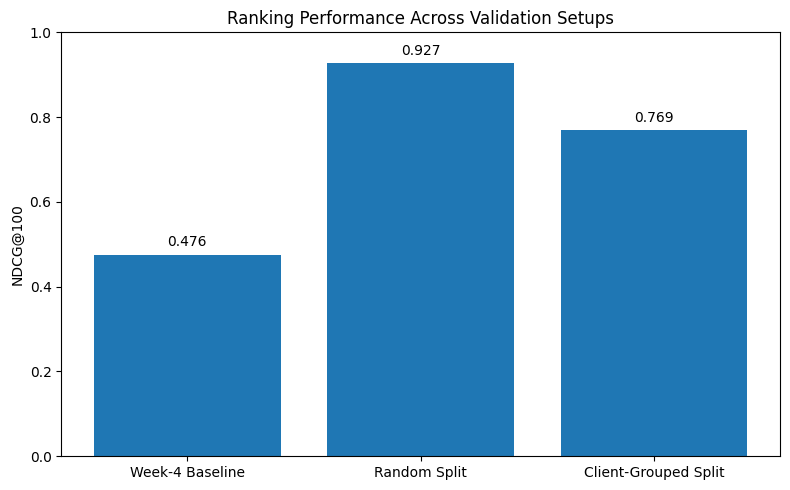

In [ ]:
import matplotlib.pyplot as plt

labels = [
    "Week-4 Baseline",
    "Random Split",
    "Client-Grouped Split"
]

scores = [
    0.475782,
    0.926767,
    0.769499
]

plt.figure(figsize=(8, 5))
plt.bar(labels, scores)
plt.ylabel("NDCG@100")
plt.title("Ranking Performance Across Validation Setups")
plt.ylim(0, 1)

for i, score in enumerate(scores):
    plt.text(i, score + 0.02, f"{score:.3f}", ha="center")

plt.tight_layout()
plt.show()

**Takeaway:** The Random Forest ranked declining content better than the baseline, but its score dropped from 0.927 on the random split to 0.769 on the client-grouped split, showing why the grouped result is the more cautious estimate.

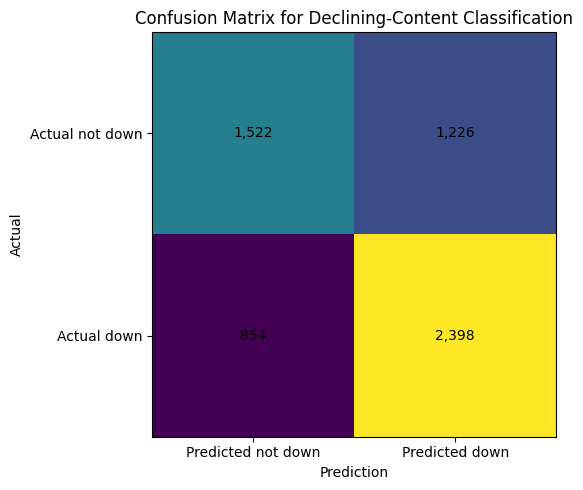

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

cm = np.array([
    [1522, 1226],
    [854, 2398]
])

fig, ax = plt.subplots(figsize=(7, 5))

im = ax.imshow(cm)

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])

ax.set_xticklabels(["Predicted not down", "Predicted down"])
ax.set_yticklabels(["Actual not down", "Actual down"])

ax.set_xlabel("Prediction")
ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix for Declining-Content Classification")

for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{cm[i, j]:,}", ha="center", va="center")

plt.tight_layout()
plt.show()

**Note:** This confusion matrix comes from the original random-split validation result, not the later client-grouped validation.

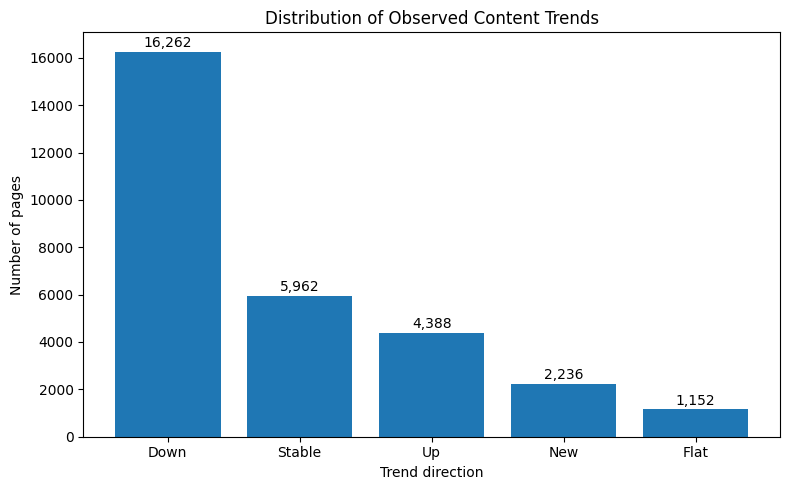

In [ ]:
import matplotlib.pyplot as plt

trend_counts = {
    "Down": 16262,
    "Stable": 5962,
    "Up": 4388,
    "New": 2236,
    "Flat": 1152
}

plt.figure(figsize=(8, 5))

bars = plt.bar(trend_counts.keys(), trend_counts.values())

plt.title("Distribution of Observed Content Trends")
plt.xlabel("Trend direction")
plt.ylabel("Number of pages")

for bar, value in zip(bars, trend_counts.values()):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 200,
        f"{value:,}",
        ha="center"
    )

plt.tight_layout()
plt.show()

**Takeaway:** Declining pages were the largest group in the modeling dataset, with 16,262 of 30,000 pages classified as down, so the model was evaluated against a strongly imbalanced target rather than an even five-class distribution.

## 5. Limitations

*What this work cannot claim.*

There are several reasons to treat these results as directional rather than as a guarantee of future performance.

First, the original random train/validation split may give an optimistic estimate because pages from the same clients can appear in both training and validation. The client-grouped evaluation was more conservative, with an NDCG@100 of 0.769499 compared with 0.926767 on the random split. :contentReference[oaicite:1]{index=1}

Second, the starter dataset does not provide enough information to completely verify temporal separation between the features and the target. I therefore cannot claim that temporal leakage has been fully ruled out. :contentReference[oaicite:2]{index=2}

Third, the dataset represents observed search performance rather than the reasons behind that performance. The model can identify patterns associated with declining pages, but it cannot explain whether the decline was caused by content quality, competitors, search-engine changes, seasonality, or another factor.

Finally, this analysis does not prove that refreshing a page will improve its future search performance. The model should therefore be treated as a **decision-support tool for prioritizing human review**, not as an automatic content-refresh system. :contentReference[oaicite:3]{index=3}

The results are best described as observed and directional findings from this dataset and validation design. Further testing on future time periods and unseen clients would be needed before making stronger claims about generalization.

In [ ]:
limitations_checks = {
    "Random split may be optimistic": True,
    "Client-grouped validation performed": True,
    "Temporal leakage fully verified": False,
    "Causal effect of content refresh measured": False,
    "Automatic publishing/rewrite recommended": False
}

for check, result in limitations_checks.items():
    print(f"{check}: {result}")

Random split may be optimistic: True
Client-grouped validation performed: True
Temporal leakage fully verified: False
Causal effect of content refresh measured: False
Automatic publishing/rewrite recommended: False


## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

The model is most useful as a prioritization tool. Its output should help a person decide which pages deserve attention first rather than automatically deciding what should happen to a page.

### 1. Review pages ranked as high priority first

Pages near the top of the ranking should be reviewed first because the model is designed to surface content showing stronger signals of decline. A human reviewer should then check the page's search performance and decide whether further investigation is worthwhile.

### 2. Check the reason for the decline before taking action

A high score does not explain why performance changed. Before refreshing a page, the reviewer should consider factors such as recent performance, search position, content freshness, and other available context.

### 3. Use the ranking to prioritize work, not to automate content changes

The model should not automatically rewrite, publish, or delete content. Its role is to reduce the number of pages that need to be considered manually and help focus attention on higher-priority cases.

### 4. Treat borderline cases as review candidates

Pages near the middle of the ranking should not automatically be ignored. If other evidence suggests that a page needs attention, it can still be reviewed even if the model gives it a lower priority.

### 5. Re-test the ranking on future and unseen data

Because performance dropped from 0.926767 on the random split to 0.769499 on the client-grouped split, future evaluation should include unseen clients and, where possible, a genuinely time-separated validation period.

### Recommended action flow

**Model ranking → human review → investigate the cause → decide whether a refresh is appropriate → measure the outcome.**

The model provides the ranking; the final content decision remains with the reviewer.

In [ ]:
recommendations = [
    "Review high-priority pages first",
    "Investigate the reason for decline",
    "Do not automate content changes",
    "Review borderline cases using additional evidence",
    "Re-test on future and unseen data"
]

print("Ranked recommendations:")
for i, recommendation in enumerate(recommendations, start=1):
    print(f"{i}. {recommendation}")

Ranked recommendations:
1. Review high-priority pages first
2. Investigate the reason for decline
3. Do not automate content changes
4. Review borderline cases using additional evidence
5. Re-test on future and unseen data


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

In [ ]:
import os

FIGURES_DIR = "work/figures"
os.makedirs(FIGURES_DIR, exist_ok=True)

print("Figures folder ready:", os.path.exists(FIGURES_DIR))

Figures folder ready: True


In [ ]:
plt.savefig(
    "work/figures/ranking_performance.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

<Figure size 640x480 with 0 Axes>

In [ ]:
plt.tight_layout()

plt.savefig(
    "work/figures/ranking_performance.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

<Figure size 640x480 with 0 Axes>

In [ ]:
plt.savefig(
    "work/figures/confusion_matrix.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

<Figure size 640x480 with 0 Axes>

In [ ]:
plt.savefig(
    "work/figures/trend_distribution.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

<Figure size 640x480 with 0 Axes>

In [ ]:
import os

figure_files = [
    "work/figures/ranking_performance.png",
    "work/figures/confusion_matrix.png",
    "work/figures/trend_distribution.png"
]

print("Paper figures:")

for file in figure_files:
    print(
        file,
        "→",
        "OK" if os.path.exists(file) else "MISSING"
    )

Paper figures:
work/figures/ranking_performance.png → OK
work/figures/confusion_matrix.png → OK
work/figures/trend_distribution.png → OK


The paper uses three main figures to communicate the results.

1. **Ranking performance:** compares the Week-4 baseline with the Random Forest on the random and client-grouped validation setups.
2. **Confusion matrix:** shows the classification results for declining versus non-declining pages on the original random-split validation.
3. **Trend distribution:** shows the distribution of the five observed trend classes in the 30,000-row modeling dataset.

The figures are saved in `work/figures/` so they can be reused by the deployed research page.

### Results summary

| Evaluation | NDCG@100 |
|---|---:|
| Week-4 rule baseline | 0.475782 |
| Random-split Random Forest | 0.926767 |
| Client-grouped Random Forest | 0.769499 |

The random-split result shows the strongest measured improvement, while the client-grouped result provides the more cautious estimate because the validation clients were not seen during training.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.


In [ ]:
import threading
import http.server
import socketserver

PORT = 8000

handler = lambda *args, **kwargs: http.server.SimpleHTTPRequestHandler(
    *args, directory="/content/ML-Projects", **kwargs
)

server = socketserver.TCPServer(("", PORT), handler)

thread = threading.Thread(target=server.serve_forever)
thread.daemon = True
thread.start()

print(f"Server running on port {PORT}")

Server running on port 8000


In [ ]:
from google.colab import output

output.serve_kernel_port_as_window(PORT)

Try `serve_kernel_port_as_iframe` instead. 


<IPython.core.display.Javascript object>

/content/ML-Projects


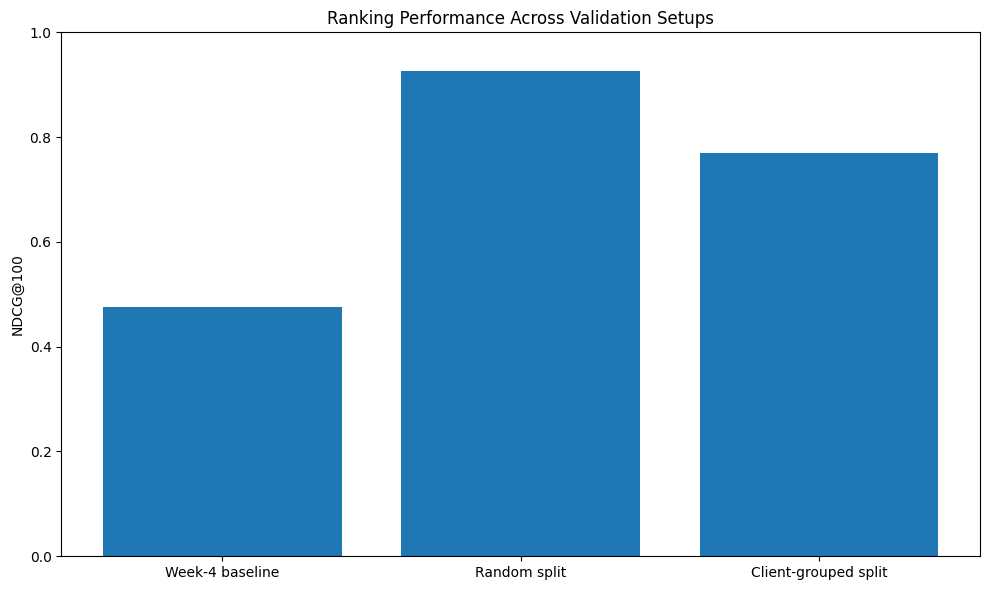

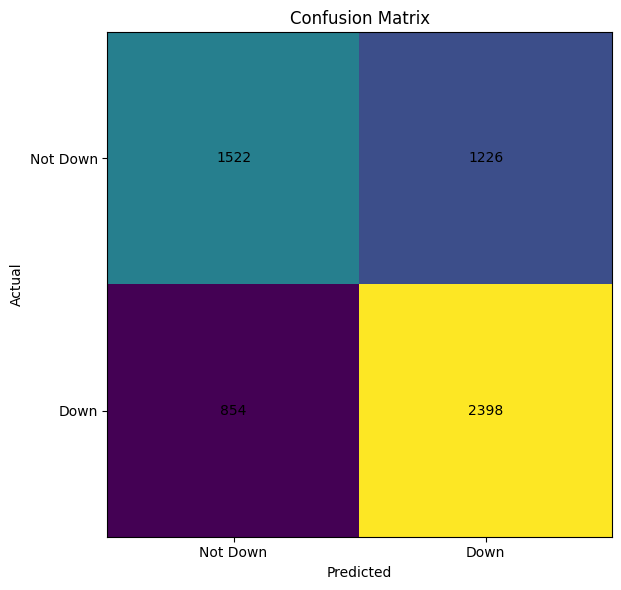

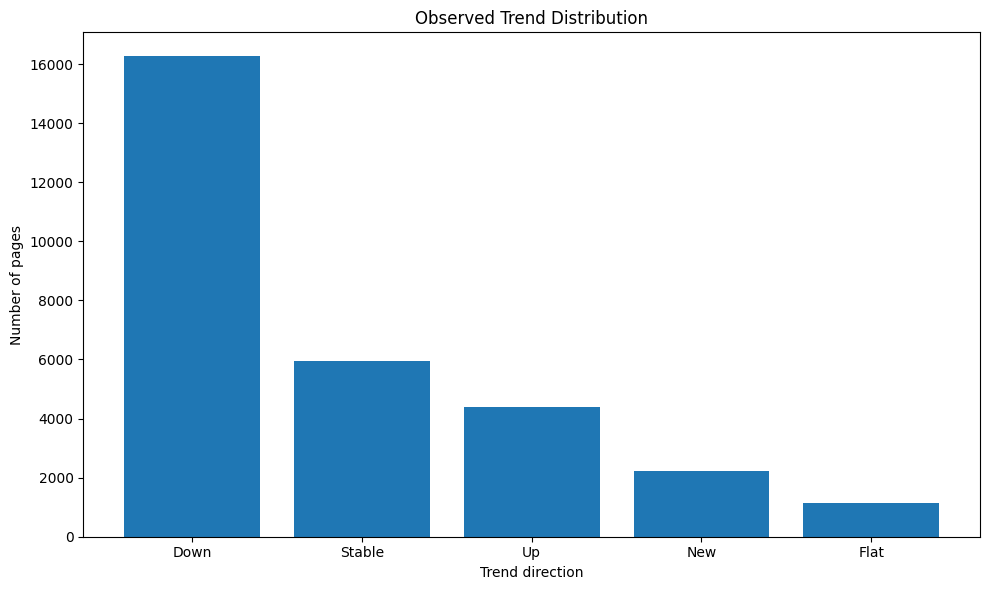

All three charts regenerated.


In [ ]:
%cd /content/ML-Projects

import os
import matplotlib.pyplot as plt

os.makedirs("work/figures", exist_ok=True)

# -----------------------------
# 1. Ranking performance
# -----------------------------
labels = [
    "Week-4 baseline",
    "Random split",
    "Client-grouped split"
]

scores = [
    0.475782,
    0.926767,
    0.769499
]

plt.figure(figsize=(10, 6))
plt.bar(labels, scores)
plt.ylabel("NDCG@100")
plt.title("Ranking Performance Across Validation Setups")
plt.ylim(0, 1.0)
plt.tight_layout()

plt.savefig(
    "work/figures/ranking_performance.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()
plt.close()


# -----------------------------
# 2. Confusion matrix
# -----------------------------
cm = [
    [1522, 1226],
    [854, 2398]
]

plt.figure(figsize=(7, 6))
plt.imshow(cm)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks([0, 1], ["Not Down", "Down"])
plt.yticks([0, 1], ["Not Down", "Down"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i][j], ha="center", va="center")

plt.tight_layout()

plt.savefig(
    "work/figures/confusion_matrix.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()
plt.close()


# -----------------------------
# 3. Trend distribution
# -----------------------------
trend_labels = [
    "Down",
    "Stable",
    "Up",
    "New",
    "Flat"
]

trend_counts = [
    16262,
    5962,
    4388,
    2236,
    1152
]

plt.figure(figsize=(10, 6))
plt.bar(trend_labels, trend_counts)

plt.ylabel("Number of pages")
plt.xlabel("Trend direction")
plt.title("Observed Trend Distribution")

plt.tight_layout()

plt.savefig(
    "work/figures/trend_distribution.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()
plt.close()

print("All three charts regenerated.")

In [ ]:
from PIL import Image
import numpy as np

img = Image.open(
    "/content/ML-Projects/work/figures/ranking_performance.png"
).convert("RGB")

arr = np.array(img)

print("Minimum:", arr.min())
print("Maximum:", arr.max())
print("Mean:", arr.mean())

Minimum: 0
Maximum: 255
Mean: 184.77480635443283


In [ ]:
%cd /content/ML-Projects

/content/ML-Projects


In [ ]:
import os

print(os.path.exists("docs"))
print(os.listdir("docs"))

True
['ml-intern-dataset-and-lane-guide.md', 'ml-core-foundation-framework.md', 'intern-free-tooling-guide.md', 'flyrank-seo-research-march-2026.pdf', 'data-dictionary.md']


In [ ]:
html_path = "docs/index.html"

if not os.path.exists(html_path):
    with open(html_path, "w", encoding="utf-8") as f:
        f.write("""<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>Capstone Research Paper</title>
</head>

<body>

    <h1>Capstone Research Paper</h1>

    <p>This research page is currently being prepared.</p>

</body>
</html>
""")

print("Created:", html_path)

Created: docs/index.html


In [ ]:
print(os.path.exists("docs/index.html"))

True


In [ ]:
%cd /content/ML-Projects

import os

print("Current directory:", os.getcwd())
print("docs folder exists:", os.path.exists("docs"))
print("index.html exists:", os.path.exists("docs/index.html"))

/content/ML-Projects
Current directory: /content/ML-Projects
docs folder exists: True
index.html exists: True


In [ ]:
html_path = "docs/index.html"

with open(html_path, "w", encoding="utf-8") as f:
    f.write("""<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>Capstone Research Paper</title>
</head>
<body>

    <h1>Capstone Research Paper</h1>

    <p>Research paper coming soon.</p>

</body>
</html>
""")

print("Created:", html_path)

Created: docs/index.html


In [ ]:
%cd /content/ML-Projects

from pathlib import Path

html_path = Path("docs/index.html")

html = html_path.read_text(encoding="utf-8")

# Fix figure paths for a page located inside docs/
html = html.replace(
    'src="work/figures/',
    'src="../work/figures/'
)

html = html.replace(
    "src='work/figures/",
    "src='../work/figures/"
)

html_path.write_text(html, encoding="utf-8")

print("Image paths fixed.")

/content/ML-Projects
Image paths fixed.


In [ ]:
%cd /content/ML-Projects

html = """<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">

    <title>Ranking Declining Content Using Search Performance Signals</title>

    <style>
        body {
            font-family: Arial, sans-serif;
            line-height: 1.7;
            max-width: 900px;
            margin: 0 auto;
            padding: 40px 20px;
            color: #222;
        }

        h1 {
            line-height: 1.2;
            margin-bottom: 10px;
        }

        h2 {
            margin-top: 45px;
            border-bottom: 1px solid #ddd;
            padding-bottom: 8px;
        }

        h3 {
            margin-top: 30px;
        }

        .subtitle {
            color: #666;
            font-size: 1.05rem;
        }

        .abstract {
            background: #f5f5f5;
            padding: 20px;
            border-radius: 8px;
        }

        .result-box {
            background: #f8f8f8;
            padding: 18px;
            border-left: 4px solid #555;
            margin: 20px 0;
        }

        table {
            width: 100%;
            border-collapse: collapse;
            margin: 20px 0;
        }

        th, td {
            border: 1px solid #ddd;
            padding: 10px;
            text-align: left;
        }

        th {
            background: #f5f5f5;
        }

        img {
            display: block;
            max-width: 100%;
            height: auto;
            margin: 20px auto;
        }

        .caption {
            text-align: center;
            color: #666;
            font-size: 0.95rem;
        }

        li {
            margin-bottom: 12px;
        }

        a {
            color: #2457a6;
        }

        footer {
            margin-top: 60px;
            padding-top: 20px;
            border-top: 1px solid #ddd;
            color: #666;
        }
    </style>
</head>

<body>

    <!-- 1. TITLE + ABSTRACT -->
    <header>
        <h1>Ranking Declining Content Using Search Performance Signals</h1>

        <p class="subtitle">
            A decision-support approach for prioritizing content pages for human review
        </p>

        <div class="abstract">
            <h2>Abstract</h2>

            <p>
                This study asks whether search-performance signals can help prioritize
                content pages that show signs of decline. Using the FlyRank internship
                modeling dataset, the analysis evaluates search-performance features
                including impressions, clicks, average position, and days since last
                update. A Random Forest model was compared with a Week-4 rule-based
                baseline using NDCG@100. The model achieved an NDCG@100 of 0.926767
                on a random split and 0.769499 on a client-grouped split, compared
                with 0.475782 for the baseline. These results suggest that the model
                can support prioritization of pages for human review, but they do not
                establish that refreshing a page will cause better future performance.
            </p>
        </div>
    </header>


    <!-- 2. INTRODUCTION / PROBLEM -->
    <section>
        <h2>1. Introduction / Problem</h2>

        <p>
            Content teams may have many pages to review but limited time to decide
            which pages deserve attention first. The practical question in this
            project is whether observed search-performance signals can be used to
            rank pages so that potentially declining content can be reviewed earlier.
        </p>

        <p>
            The goal is therefore not to automatically rewrite or publish content.
            Instead, the model is treated as a decision-support tool that can help
            reduce a large set of pages to a more manageable review queue.
        </p>
    </section>


    <!-- 3. DATA -->
    <section>
        <h2>2. Data</h2>

        <p>
            The analysis uses the FlyRank internship dataset. The modeling work
            uses a 30,000-row dataset with 44 columns, while the broader warehouse
            exploration included the <code>fact_content_query_90d</code> release
            containing 2,414,248 rows and 21 fields.
        </p>

        <p>
            The warehouse table represents content-query observations over a
            90-day window. The observed window in the inspected warehouse release
            runs from April 2, 2026 to June 30, 2026.
        </p>

        <p>
            Client, content, and query identifiers were treated as identifiers and
            were not used as model features. The modeling features were selected
            to describe observed search performance rather than expose private
            identifiers or raw queries.
        </p>

        <p>
            The analysis does not include private client names, raw search queries,
            or other identifying information in this public paper.
        </p>
    </section>


    <!-- 4. METHODOLOGY -->
    <section>
        <h2>3. Methodology</h2>

        <h3>Features</h3>

        <p>
            The final model used four features:
        </p>

        <ul>
            <li><code>impressions_90d</code></li>
            <li><code>clicks_90d</code></li>
            <li><code>avg_position</code></li>
            <li><code>days_since_last_update</code></li>
        </ul>

        <h3>Target</h3>

        <p>
            The target was <code>trend_direction</code>. The modeling dataset
            contained five observed trend classes: down, stable, up, new, and flat.
        </p>

        <h3>Baseline</h3>

        <p>
            The Week-4 rule-based baseline achieved an NDCG@100 of 0.475782.
            The Random Forest model was evaluated against this baseline using
            the same ranking metric.
        </p>

        <h3>Validation</h3>

        <p>
            Two validation setups were examined. The random split produced an
            NDCG@100 of 0.926767. A client-grouped split, designed to provide a
            more conservative test on unseen clients, produced an NDCG@100 of
            0.769499.
        </p>

        <h3>Leakage checks</h3>

        <p>
            The final feature audit found no target-derived columns accidentally
            included as model features, and client identifiers were not used as
            model features. Temporal leakage could not be fully verified from the
            available starter dataset, so the results are framed as directional
            rather than causal evidence.
        </p>
    </section>


    <!-- 5. RESULTS -->
    <section>
        <h2>4. Results</h2>

        <p>
            The model improved substantially over the Week-4 baseline on both
            validation setups. However, the grouped result was lower than the
            random-split result, which makes it the more cautious estimate of
            performance.
        </p>

        <table>
            <thead>
                <tr>
                    <th>Evaluation</th>
                    <th>NDCG@100</th>
                </tr>
            </thead>
            <tbody>
                <tr>
                    <td>Week-4 rule baseline</td>
                    <td>0.475782</td>
                </tr>
                <tr>
                    <td>Random-split Random Forest</td>
                    <td>0.926767</td>
                </tr>
                <tr>
                    <td>Client-grouped Random Forest</td>
                    <td>0.769499</td>
                </tr>
            </tbody>
        </table>

        <div class="result-box">
            <strong>Key result:</strong>
            The client-grouped NDCG@100 of 0.769499 provides the more cautious
            estimate because the validation design separates clients between
            training and validation.
        </div>

        <h3>Ranking performance</h3>

        <img src="../work/figures/ranking_performance.png"
             alt="Ranking performance across validation setups">

        <p class="caption">
            Ranking performance across the baseline, random split, and
            client-grouped validation setups.
        </p>

        <p>
            <strong>Takeaway:</strong> The Random Forest ranked declining content
            better than the baseline, but its score dropped from 0.927 on the
            random split to 0.769 on the client-grouped split.
        </p>


        <h3>Classification behavior</h3>

        <img src="../work/figures/confusion_matrix.png"
             alt="Confusion matrix for declining-content classification">

        <p class="caption">
            Confusion matrix from the original random-split validation result.
        </p>

        <p>
            <strong>Takeaway:</strong> The model correctly identified 2,398 of
            the 3,252 declining pages in this validation result, while missing
            854 and incorrectly flagging 1,226 pages that were not classified
            as declining.
        </p>


        <h3>Observed trend distribution</h3>

        <img src="../work/figures/trend_distribution.png"
             alt="Distribution of observed content trends">

        <p class="caption">
            Distribution of the five observed trend classes in the
            30,000-row modeling dataset.
        </p>

        <p>
            <strong>Takeaway:</strong> Declining pages were the largest group in
            the modeling dataset, with 16,262 of 30,000 pages classified as down.
        </p>
    </section>


    <!-- 6. LIMITATIONS -->
    <section>
        <h2>5. Limitations &amp; Honest Framing</h2>

        <p>
            The original random train/validation split may provide an optimistic
            estimate because pages from the same clients can appear in both
            training and validation. The client-grouped evaluation provides a
            more conservative result.
        </p>

        <p>
            Temporal leakage could not be fully verified from the available
            starter dataset. This means the analysis cannot claim that temporal
            separation has been completely established.
        </p>

        <p>
            The data describes observed search performance but does not explain
            why performance changed. Factors such as content quality, competitors,
            seasonality, or search-engine changes are not established as causes
            by this analysis.
        </p>

        <p>
            Most importantly, this study does not prove that refreshing content
            will improve future search performance. The model should therefore be
            used for decision support and human review rather than automatic
            publishing, rewriting, or deletion.
        </p>
    </section>


    <!-- 7. RECOMMENDATIONS -->
    <section>
        <h2>6. Ranked Recommendations</h2>

        <ol>
            <li>
                <strong>Review high-priority pages first.</strong>
                Pages near the top of the model ranking should receive human
                review before lower-priority pages.
            </li>

            <li>
                <strong>Check the reason for the decline.</strong>
                A high score does not explain why performance changed, so
                reviewers should investigate the available evidence before
                deciding on an action.
            </li>

            <li>
                <strong>Use the ranking to prioritize work, not automate
                content changes.</strong>
                The model should not automatically rewrite, publish, or delete
                content.
            </li>

            <li>
                <strong>Review borderline cases using additional evidence.</strong>
                A lower model score should not automatically mean that a page
                is ignored.
            </li>

            <li>
                <strong>Re-test on future and unseen data.</strong>
                Future evaluation should include unseen clients and, where
                possible, genuinely time-separated validation data.
            </li>
        </ol>

        <div class="result-box">
            <strong>Recommended action flow:</strong><br>
            Model ranking → human review → investigate the cause →
            decide whether a refresh is appropriate → measure the outcome.
        </div>
    </section>


    <!-- 8. REPRODUCIBILITY -->
    <section>
        <h2>7. Reproducibility</h2>

        <p>
            The analysis is backed by the project repository and the capstone
            notebook used to organize the research question, data, methodology,
            validation, results, limitations, and recommendations.
        </p>

        <ul>
            <li>
                <strong>Repository:</strong>
                <a href="https://github.com/Khadija-Azam05/ML-Projects"
                   target="_blank">
                    GitHub repository
                </a>
            </li>

            <li>
                <strong>Capstone notebook:</strong>
                <code>work/notebooks/capstone.ipynb</code>
            </li>

            <li>
                <strong>Figures:</strong>
                <code>work/figures/</code>
            </li>
        </ul>

        <p>
            The reported metrics are NDCG@100 values from the documented
            validation setups. The random split and client-grouped split should
            be interpreted separately rather than treated as interchangeable
            estimates.
        </p>
    </section>


    <!-- 9. ACKNOWLEDGMENTS -->
    <section>
        <h2>8. Acknowledgments &amp; Data Credit</h2>

        <p>
            Built on the
            <strong>FlyRank ML Internship dataset</strong>.
        </p>

        <p>
            Data source:
            <a href="https://flyrank.ai" target="_blank">
                flyrank.ai
            </a>
        </p>
    </section>


    <footer>
        <p>
            This research artifact presents observed and measured results from
            the stated dataset and validation designs. The findings are intended
            for decision support and should not be interpreted as causal evidence.
        </p>
    </footer>

</body>
</html>
"""

with open("docs/index.html", "w", encoding="utf-8") as f:
    f.write(html)

print("Research paper page created.")
print("File exists:", os.path.exists("docs/index.html"))

/content/ML-Projects
Research paper page created.
File exists: True


In [ ]:
import re

html = open(
    "/content/ML-Projects/docs/index.html",
    encoding="utf-8"
).read()

for match in re.findall(r'(?:src|href)=["\']([^"\']+)["\']', html):
    if "figure" in match or ".png" in match:
        print(match)

../work/figures/ranking_performance.png
../work/figures/confusion_matrix.png
../work/figures/trend_distribution.png


In [ ]:
from IPython.display import display, HTML

html = open(
    "/content/ML-Projects/docs/index.html",
    encoding="utf-8"
).read()

display(HTML(html))

Evaluation,NDCG@100
Week-4 rule baseline,0.475782
Random-split Random Forest,0.926767
Client-grouped Random Forest,0.769499


In [ ]:
from PIL import Image
import os

path = "/content/ML-Projects/work/figures/ranking_performance.png"

print("Exists:", os.path.exists(path))

if os.path.exists(path):
    img = Image.open(path)
    print("Format:", img.format)
    print("Size:", img.size)
    print("Mode:", img.mode)

Exists: True
Format: PNG
Size: (1980, 1178)
Mode: RGBA


In [ ]:
import numpy as np
from PIL import Image

img = Image.open("/content/ML-Projects/work/figures/ranking_performance.png").convert("RGB")

arr = np.array(img)

print("Minimum pixel value:", arr.min())
print("Maximum pixel value:", arr.max())
print("Mean pixel value:", arr.mean())

Minimum pixel value: 0
Maximum pixel value: 255
Mean pixel value: 184.77480635443283


In [ ]:
%cd /content/ML-Projects

from pathlib import Path

html_path = Path("docs/index.html")

html = html_path.read_text(encoding="utf-8")

# Fix figure paths for a page located inside docs/
html = html.replace(
    'src="work/figures/',
    'src="../work/figures/'
)

html = html.replace(
    "src='work/figures/",
    "src='../work/figures/"
)

html_path.write_text(html, encoding="utf-8")

print("Image paths fixed.")

/content/ML-Projects
Image paths fixed.


In [ ]:
from google.colab import output

output.serve_kernel_port_as_iframe(8000)

<IPython.core.display.Javascript object>

In [ ]:
%cd /content/ML-Projects
!git status

/content/ML-Projects
On branch main
Your branch is up to date with 'origin/main'.

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	docs/index.html
	work/figures/

nothing added to commit but untracked files present (use "git add" to track)


In [ ]:
%cd /content/ML-Projects

!git add docs/index.html work/figures/

/content/ML-Projects


In [ ]:
!git status --short

A  docs/index.html
A  work/figures/confusion_matrix.png
A  work/figures/ranking_performance.png
A  work/figures/trend_distribution.png


In [ ]:
%cd /content/ML-Projects

!git commit -m "Add capstone research paper and figures"

/content/ML-Projects
Author identity unknown

*** Please tell me who you are.

Run

  git config --global user.email "you@example.com"
  git config --global user.name "Your Name"

to set your account's default identity.
Omit --global to set the identity only in this repository.

fatal: unable to auto-detect email address (got 'root@ad5a671ab5f3.(none)')


In [ ]:
%cd /content/ML-Projects

!git config user.name "Khadija-Azam05"
!git config user.email "hk0438797@gmail.com"

/content/ML-Projects


In [ ]:
!git config user.name
!git config user.email

Khadija-Azam05
hk0438797@gmail.com


In [ ]:
!git commit -m "Add capstone research paper and figures"

[main bec05a1] Add capstone research paper and figures
 4 files changed, 467 insertions(+)
 create mode 100644 docs/index.html
 create mode 100644 work/figures/confusion_matrix.png
 create mode 100644 work/figures/ranking_performance.png
 create mode 100644 work/figures/trend_distribution.png


In [ ]:
!git push origin main

fatal: could not read Username for 'https://github.com': No such device or address


In [ ]:
!gh --version

gh version 2.97.0 (2026-07-31)
https://github.com/cli/cli/releases/tag/v2.97.0


In [ ]:
!gh auth status

You are not logged into any GitHub hosts. To log in, run: gh auth login


In [ ]:
import getpass
import subprocess

token = getpass.getpass("Paste NEW GitHub token: ")

result = subprocess.run(
    ["gh", "auth", "login", "--with-token"],
    input=token + "\n",
    text=True,
    capture_output=True
)

del token

if result.returncode == 0:
    print("GitHub authentication successful ✅")
else:
    print("Authentication failed ❌")
    print(result.stderr)

Paste NEW GitHub token: ··········
GitHub authentication successful ✅


In [ ]:
%cd /content/ML-Projects
!git push origin main

/content/ML-Projects
fatal: could not read Username for 'https://github.com': No such device or address


In [ ]:
!gh auth setup-git

In [ ]:
%cd /content/ML-Projects
!git push origin main

/content/ML-Projects
Enumerating objects: 12, done.
Counting objects: 100% (12/12), done.
Delta compression using up to 2 threads
Compressing objects: 100% (9/9), done.
Writing objects: 100% (9/9), 110.38 KiB | 6.90 MiB/s, done.
Total 9 (delta 3), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (3/3), completed with 3 local objects.
To https://github.com/Khadija-Azam05/ML-Projects.git
   197bde0..bec05a1  main -> main


In [ ]:
%cd /content/ML-Projects

with open("submission/paper_url.txt", "w") as f:
    f.write("https://khadija-azam05.github.io/ML-Projects/\n")

print(open("submission/paper_url.txt").read())

/content/ML-Projects
https://khadija-azam05.github.io/ML-Projects/



In [ ]:
%cd /content/ML-Projects

!git status
!git add submission/paper_url.txt
!git commit -m "Add deployed paper URL"
!git push origin main

/content/ML-Projects
On branch main
Your branch is up to date with 'origin/main'.

Changes not staged for commit:
  (use "git add <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	modified:   submission/paper_url.txt

no changes added to commit (use "git add" and/or "git commit -a")
[main 84ed388] Add deployed paper URL
 1 file changed, 1 insertion(+), 1 deletion(-)
Enumerating objects: 7, done.
Counting objects: 100% (7/7), done.
Delta compression using up to 2 threads
Compressing objects: 100% (3/3), done.
Writing objects: 100% (4/4), 404 bytes | 404.00 KiB/s, done.
Total 4 (delta 1), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (1/1), completed with 1 local object.
To https://github.com/Khadija-Azam05/ML-Projects.git
   bec05a1..84ed388  main -> main
